# ANFIS-FCM sMoE U-Net — Explainable Edge Detection
### v4 — Diagnostics, native XAI, and two real bugs fixed (architecture unchanged)

Builds on v3 (root-cause convergence fixes). This version adds numerical
stability and diagnostic/XAI features recommended in a follow-up review,
**without touching** the U-Net encoder/decoder, the 3 sMoE blocks, Sobel
preprocessing, or the LSE consequent-initialization already in place.

**Two real bugs found by actually running v3 on Kaggle are fixed here too:**
1. Phase 0b called `model(imgs)` directly on **full-resolution validation
   images**, which aren't guaranteed divisible by 16 -- causes an encoder/
   decoder skip-connection shape mismatch. Now uses the shared
   `pad_to_multiple` / `predict_native` utilities (moved earlier in the
   notebook so Phase 0b can use them instead of duplicating them).
2. The per-candidate sigma computation `um[k] * (X - ck[None,:])**2` doesn't
   broadcast (`(N,)` against `(N,2)`) and throws a `ValueError` in real
   execution -- fixed with explicit `um[k].reshape(-1,1)`.

**Explicitly NOT changed, per your instruction:** `init_consequents_lse()` is
untouched -- no ridge-LSE changes, same closed-form solve as v3.

| Review item | Added? |
|---|---|
| Rule-collapse diagnostics (mean/max firing, dominance %) | ✅ |
| Stable σ: `softplus(ρ)+ε` reparameterization + log-domain Gaussian | ✅ |
| Ridge-LSE change | ❌ explicitly excluded per your instruction |
| Feature-drift monitoring (x2 before vs after backbone unfreeze) | ✅ |
| Backbone-vs-ANFIS direct comparison (P_backbone vs P_ANFIS on ODS/OIS/AP) | ✅ |
| Rule contribution maps (`w̄ᵢ × TSKᵢ`, distinct from firing maps) | ✅ |
| Entropy/uncertainty map | ✅ |
| Rule semantic profiling table | ✅ |
| FCM seed stability (Adjusted Rand Index across 5 seeds) | ✅ |
| Calibration (ECE/Brier), λ ablation, multi-seed final eval | Not added — flagged as optional follow-ups to keep this response scoped |
| Model checkpoint saving / Kaggle auto-save | **Removed** — best weights are kept in memory only (`copy.deepcopy` of `state_dict`), nothing is written to disk |


In [5]:
import torch, sys
print('Python:', sys.version)
print('Torch :', torch.__version__)
print('CUDA  :', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU   :', torch.cuda.get_device_name(0))
    print(f'VRAM  : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)


Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Torch : 2.10.0+cu128
CUDA  : True
GPU   : Tesla T4
VRAM  : 15.6 GB
Device: cuda


In [6]:
!pip install -q numpy matplotlib opencv-python-headless scipy Pillow tqdm scikit-learn
print('Dependencies installed')


Dependencies installed


## Cell — Imports & Configuration

In [7]:
import os, warnings, random, math, time, copy
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import cv2
from tqdm import tqdm
import scipy.io
from PIL import Image
from scipy.stats import wasserstein_distance
from sklearn.metrics import adjusted_rand_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
import torchvision.transforms as T
from sklearn.metrics import auc

warnings.filterwarnings('ignore')

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

BATCH_SIZE    = 4
LAMBDA_DICE   = 0.5
BASE_CH       = 64

CROP_SIZE             = 320
TILE_SIZE             = CROP_SIZE
TILE_STRIDE           = CROP_SIZE // 2
PAD_MULTIPLE          = 16
EDGE_CROP_PROB        = 0.30
SCALE_RANGE           = (0.6, 1.8)
EVAL_FULL_IMAGE_FIRST = True

# No checkpoint directory needed anymore -- best weights are kept in memory
# only. WORK_DIR is used solely for saved figures (plots), not model state.
WORK_DIR  = '/kaggle/working/smoe_results_v4'
BSR_ROOT  = '/kaggle/working/BSR/BSDS500'
os.makedirs(WORK_DIR, exist_ok=True)

# --- §6.2 FCM Clustering & Rule Count Determination -------------------------
FCM_CANDIDATE_R     = [4, 6, 8, 10, 12]
FCM_SEEDS           = 5
FCM_SAMPLE_PIXELS   = 1_000_000
FCM_MAX_ITER        = 60
FCM_M               = 2.0

FCM_SAMPLING_MODE   = 'balanced'   # 'natural' | 'balanced' | 'ratio_25_75'
# Suggestion #3: raised from 0.30 -- tests whether a richer edge-pixel presence
# in FCM's training sample yields cleaner, more separated clusters (and makes
# R=6/8 more genuinely competitive against R=4 in the validation-ODS proxy).
FCM_EDGE_FRACTION   = 0.50
FCM_EDGE_GT_THRESH  = 0.3

# Suggestion #1: z-score standardize (x1, x2) before FCM/Xie-Beni, then convert
# cluster centers/sigmas back to raw [0,1] units immediately after (the Gaussian
# MFs and the LSE fit both operate in raw units, not standardized ones). This
# only changes clustering's preprocessing convention -- FCM still runs on the
# same (x1, x2) pair, no new component. Set False to reproduce the old
# unstandardized behavior for an A/B comparison.
FCM_STANDARDIZE_FEATURES = True

XB_SHORTLIST_MARGIN  = 0.15   # kept, no longer used for shortlist gating (see fix below)
XB_SHORTLIST_TOP_K   = 3      # FIX: shortlist = best-K candidates by rank, not by tolerance.
                               # Tolerance-based gating collapsed to [4] whenever Xie-Beni
                               # degrades steeply with R (as observed on this feature space),
                               # never letting R=6/8 reach the validation-ODS comparison step
                               # the methodology relies on for the final R* decision.
R_STAR_PARSIMONY_TOL = 0.003
PROXY_ODS_THRESHOLDS = 21
PROXY_TOL_PIX        = 2

# Suggestion #2: lengthened proxy fine-tune budget (was 8). At 8 epochs the
# R=4/6/8 validation-ODS proxy spread was ~0.0008 -- too small to trust as a
# real signal. A longer, still-short, standardized budget gives genuine
# differences (if any exist) room to actually show up before R* is decided.
FCM_CANDIDATE_TRAIN_EPOCHS = 18
FCM_CANDIDATE_LR            = 5e-3

BACKBONE_WARMUP_EPOCHS = 25

# Sigma is now sigma = softplus(rho) + SIGMA_INIT_EPS -- always positive,
# differentiable, and never silently clamped/clipped (replaces v3's adaptive
# floor/ceiling clamp entirely -- review item 'stable sigma parameterization').
SIGMA_INIT_EPS = 1e-3

ALPHA_BACKBONE          = 0.3
FROZEN_BASELINE_EPOCHS  = 15
MAX_EPOCHS  = 250
PATIENCE    = 25

LR_ANFIS            = 1e-4
LR_DECODER          = 1e-5
LR_ENCODER          = 1e-6
MF_LR_MULTIPLIER    = 2
MF_FREEZE_EPOCHS       = 5
ENCODER_UNFREEZE_EPOCH = 40

GRAD_CLIP_NORM = 3.0

# --- Optional rule-diversity regularizer (methodology-safe) ----------------
# When RULE_DIVERSITY_BETA > 0, an auxiliary load-balancing term is added to
# the training loss: loss -= beta * entropy(mean_wbar_over_batch). This rewards
# more even AVERAGE rule utilization across the batch (a standard MoE load-
# balancing technique) without changing the ANFIS architecture, FCM step, or
# evaluation protocol. At beta=0.0 this term is exactly zero and training is
# byte-for-byte identical to the unmodified notebook.
# Suggestion #4: turned on at a small value. Set back to 0.0 to reproduce an
# exact baseline run for a clean before/after ablation comparison.
RULE_DIVERSITY_BETA = 0.02
# FIX: target the diversity pressure at GT-edge pixels specifically (see
# rule_balance_loss_edge_weighted in cell 12) instead of pooling over all
# pixels. Class-conditioned diagnostics showed pooled diversity still left
# one rule dominating ~50% of EDGE pixels even though background dominance
# is expected/healthy -- edge-weighting targets pressure where it matters.
# Set False to fall back to the original pooled rule_balance_loss().
RULE_DIVERSITY_EDGE_WEIGHTED = True

# FIX: post-hoc redundant-cluster merge threshold (standardized-feature units).
# FCM can satisfy its own objective by subdividing an already-dense region
# into near-duplicate clusters instead of discovering new structure (observed
# directly: 5 of 8 rules at R*=8 landed in the same coarse background region).
# Any two cluster centers closer than this threshold are merged into one
# before the ANFIS head is built. Operates on FCM's own output only.
FCM_MERGE_MIN_DIST = 0.3

# --- New diagnostics (this version) -----------------------------------------
RULE_DIAG_EVERY_N_EPOCHS   = 20   # print rule-collapse diagnostics this often in Stage B
FEATURE_DRIFT_N_BATCHES    = 20   # val batches used to capture x2 distribution snapshots
EVALUATE_BACKBONE_BASELINE = True # also run the full ODS/OIS/AP protocol on P_backbone
                                   # (doubles evaluation time -- set False to skip)

print('Config ready (v4 -- diagnostics + 2 real bugs fixed, architecture/LSE unchanged)')
print(f'Sigma parameterization: softplus(rho) + {SIGMA_INIT_EPS} (no clamp)')
print(f'Evaluate backbone baseline too: {EVALUATE_BACKBONE_BASELINE}')


Config ready (v4 -- diagnostics + 2 real bugs fixed, architecture/LSE unchanged)
Sigma parameterization: softplus(rho) + 0.001 (no clamp)
Evaluate backbone baseline too: True


## Cell — Download BSDS500 (unchanged)

In [8]:
import tarfile

BSR_TGZ = '/kaggle/working/BSR_bsds500.tgz'
BSR_DIR  = '/kaggle/working/BSR'

if not os.path.exists(os.path.join(BSR_DIR, 'BSDS500', 'data', 'images', 'train')):
    print('Downloading BSDS500...')
    os.system(f'wget -q --show-progress '
              f'https://www2.eecs.berkeley.edu/Research/Projects/CS/vision/grouping/BSR/BSR_bsds500.tgz '
              f'-O {BSR_TGZ}')
    with tarfile.open(BSR_TGZ, 'r:gz') as tar:
        tar.extractall('/kaggle/working/')
    print('Extracted.')
else:
    print('BSDS500 already present.')

for split in ['train', 'val', 'test']:
    n_img = len([f for f in os.listdir(f'{BSR_DIR}/BSDS500/data/images/{split}') if f.endswith('.jpg')])
    n_gt  = len([f for f in os.listdir(f'{BSR_DIR}/BSDS500/data/groundTruth/{split}') if f.endswith('.mat')])
    print(f'  [{split:>5}]  images={n_img}  gt_mats={n_gt}')

BSR_ROOT = f'{BSR_DIR}/BSDS500'
print('Dataset ready')


BSDS500 already present.
  [train]  images=200  gt_mats=200
  [  val]  images=100  gt_mats=100
  [ test]  images=200  gt_mats=200
Dataset ready


## Cell — Sobel Edge Detector (unchanged from v3 -- global-scale calibration)

In [9]:
class SobelEdgeDetector(nn.Module):
    def __init__(self):
        super().__init__()
        kx = torch.tensor([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=torch.float32)
        ky = torch.tensor([[-1,-2,-1],[0,0,0],[1,2,1]],  dtype=torch.float32)
        self.register_buffer('kx', kx.view(1,1,3,3))
        self.register_buffer('ky', ky.view(1,1,3,3))
        self.register_buffer('global_scale', torch.tensor(1.0))
        self.calibrated = False

    def _raw_magnitude(self, x_raw):
        gray = 0.2126*x_raw[:,0:1] + 0.7152*x_raw[:,1:2] + 0.0722*x_raw[:,2:3]
        gray = F.pad(gray, (1,1,1,1), mode='reflect')
        gx   = F.conv2d(gray, self.kx, padding=0)
        gy   = F.conv2d(gray, self.ky, padding=0)
        return torch.sqrt(gx**2 + gy**2 + 1e-8)

    def forward(self, x_raw):
        mag = self._raw_magnitude(x_raw)
        if self.calibrated:
            return (mag / self.global_scale).clamp(0, 1)
        B = mag.shape[0]
        flat = mag.view(B, -1)
        mn = flat.min(1, keepdim=True)[0].view(B,1,1,1)
        mx = flat.max(1, keepdim=True)[0].view(B,1,1,1)
        return (mag - mn) / (mx - mn + 1e-8)

    @torch.no_grad()
    def calibrate(self, x_raw_batches, percentile=99.0):
        mags = []
        for x_raw in x_raw_batches:
            mags.append(self._raw_magnitude(x_raw).flatten().cpu())
        all_mag = torch.cat(mags).numpy()
        scale = float(np.percentile(all_mag, percentile))
        self.global_scale.fill_(max(scale, 1e-4))
        self.calibrated = True
        return scale

print('SobelEdgeDetector defined -- unchanged from v3')


SobelEdgeDetector defined -- unchanged from v3


## Cell — sMoE Block (unchanged, exactly 3 instances -- e2/e3/e4)

In [10]:
class sMoEBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.context_expert = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=2, dilation=2, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
        self.boundary_expert = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
        self.gate = nn.Sequential(
            nn.Conv2d(1, 1, 1),
            nn.Sigmoid(),
        )

    def forward(self, x, edge_signal):
        e = F.interpolate(edge_signal, size=x.shape[-2:],
                          mode='bilinear', align_corners=False)
        g      = self.gate(e)
        sharp  = self.boundary_expert(x)
        smooth = self.context_expert(x)
        y      = g * sharp + (1.0 - g) * smooth
        return y, g

print('sMoEBlock defined -- unchanged (3 skip connections, Figure 1)')


sMoEBlock defined -- unchanged (3 skip connections, Figure 1)


## Cell — ANFIS Fuzzy Head + FCM/Xie-Beni utilities
### Numerical-stability and native-XAI additions (review items)

- **Stable σ:** `GaussianMF` now parameterizes sigma as
  `softplus(rho) + SIGMA_INIT_EPS` instead of a raw parameter clamped after
  the fact -- always positive, always differentiable, never silently clipped.
- **Log-domain Gaussian:** membership is computed as
  `exp(log_mu)` where `log_mu = -(x-c)^2 / (2 sigma^2)` is computed directly
  in log space before a single `exp`, avoiding repeated underflow-prone
  intermediate values.
- **`init_consequents_lse` is UNCHANGED from v3** -- no ridge-LSE edits, per
  your instruction.
- New helper functions for rule-collapse diagnostics, entropy maps, and
  per-rule contribution maps (all read off existing tensors -- no new
  architecture).


In [11]:
def fuzzy_c_means(X, c, m=2.0, max_iter=60, tol=1e-5, seed=0):
    rng = np.random.RandomState(seed)
    N, D = X.shape
    u = rng.rand(c, N); u /= u.sum(axis=0, keepdims=True)
    centers = None
    for _ in range(max_iter):
        um = u ** m
        centers = (um @ X) / um.sum(axis=1, keepdims=True).clip(min=1e-8)
        dist = np.linalg.norm(X[None, :, :] - centers[:, None, :], axis=2) + 1e-8
        new_u = 1.0 / (dist ** (2 / (m - 1)))
        new_u /= new_u.sum(axis=0, keepdims=True)
        if np.abs(new_u - u).max() < tol:
            u = new_u; break
        u = new_u
    return centers, u


def xie_beni_index(X, centers, u, m=2.0):
    dist2 = np.linalg.norm(X[None, :, :] - centers[:, None, :], axis=2) ** 2
    numer = (u ** m * dist2).sum()
    csep  = np.linalg.norm(centers[:, None, :] - centers[None, :, :], axis=2)
    np.fill_diagonal(csep, np.inf)
    denom = X.shape[0] * (csep.min() ** 2)
    return numer / max(denom, 1e-8)


def sample_pixels(x1_flat, x2_flat, gt_flat, n_take, mode, edge_fraction,
                   edge_thresh, rng):
    """Named, switchable sampling strategy: 'natural' | 'balanced' | 'ratio_25_75'.
    Returns (x1_sel, x2_sel, gt_sel)."""
    if mode == 'natural':
        n_take = min(n_take, len(x1_flat))
        sel = rng.choice(len(x1_flat), n_take, replace=False)
        return x1_flat[sel], x2_flat[sel], gt_flat[sel]

    frac = 0.25 if mode == 'ratio_25_75' else edge_fraction
    is_edge = gt_flat > edge_thresh
    edge_idx     = np.flatnonzero(is_edge)
    non_edge_idx = np.flatnonzero(~is_edge)

    n_edge_take = min(int(round(n_take * frac)), len(edge_idx))
    n_non_take  = min(n_take - n_edge_take, len(non_edge_idx))

    sel_edge = rng.choice(edge_idx, n_edge_take, replace=False) if n_edge_take > 0 else np.array([], dtype=int)
    sel_non  = rng.choice(non_edge_idx, n_non_take, replace=False) if n_non_take > 0 else np.array([], dtype=int)
    sel = np.concatenate([sel_edge, sel_non])
    return x1_flat[sel], x2_flat[sel], gt_flat[sel]


# ============================================================================
# ANFIS fuzzy head (5 layers, Jang 1993)
#   L1 Fuzzification    - GaussianMF, FCM-initialised, softplus-sigma, log-domain
#   L2 Rule firing       - product T-norm
#   L3 Normalisation     - w_i / sum(w)  -> Rule Firing Maps (XAI)
#   L4 Consequents       - nn.Parameter, LSE-INITIALIZED ONCE (unchanged from v3),
#                          then trained by backprop
#   L5 Output            - sum of weighted consequents -> sigmoid
# ============================================================================
def _inverse_softplus(y, eps=SIGMA_INIT_EPS):
    """Solve softplus(rho) + eps = y for rho, used only at initialization."""
    y_adj = max(y - eps, 1e-4)
    return math.log(math.expm1(y_adj)) if y_adj < 20 else y_adj


class GaussianMF(nn.Module):
    """sigma = softplus(rho) + eps: always positive, differentiable, never
    clamped (review safeguard B). Membership computed in log-domain before a
    single exp (review safeguard A)."""
    def __init__(self, init_center: float, init_sigma: float = 0.35, sigma_eps: float = SIGMA_INIT_EPS):
        super().__init__()
        _c0 = min(max(init_center, 1e-4), 1 - 1e-4)
        self.center_raw = nn.Parameter(torch.tensor(math.log(_c0 / (1 - _c0)), dtype=torch.float32))
        _rho0 = _inverse_softplus(max(init_sigma, sigma_eps * 2), sigma_eps)
        self.sigma_raw = nn.Parameter(torch.tensor(_rho0, dtype=torch.float32))
        self.sigma_eps = sigma_eps

    @property
    def center(self):
        return torch.sigmoid(self.center_raw)

    @property
    def sigma(self):
        return F.softplus(self.sigma_raw) + self.sigma_eps

    def forward(self, x):
        log_mu = -((x - self.center) ** 2) / (2 * self.sigma ** 2 + 1e-8)
        return torch.exp(log_mu)


class ANFISRule(nn.Module):
    def __init__(self, cx1, cx2, sigma=0.35):
        super().__init__()
        self.mf_x1 = GaussianMF(cx1, sigma)
        self.mf_x2 = GaussianMF(cx2, sigma)

    def forward(self, x1, x2):
        return self.mf_x1(x1) * self.mf_x2(x2)


class ANFISFuzzyHead(nn.Module):
    def __init__(self, n_rules=4, init_centers=None, init_sigmas=None):
        super().__init__()
        self.n_rules = n_rules
        if init_centers is None:
            init_centers = [(0.8,0.8),(0.2,0.8),(0.2,0.2),(0.8,0.2)][:n_rules]
        if init_sigmas is None:
            init_sigmas = [(0.35, 0.35)] * n_rules
        self.rules = nn.ModuleList([ANFISRule(cx1, cx2) for cx1, cx2 in init_centers])
        for rule, (s1, s2) in zip(self.rules, init_sigmas):
            rule.mf_x1.sigma_raw.data.fill_(_inverse_softplus(max(s1, SIGMA_INIT_EPS*2)))
            rule.mf_x2.sigma_raw.data.fill_(_inverse_softplus(max(s2, SIGMA_INIT_EPS*2)))
        self.consequents = nn.Parameter(torch.zeros(n_rules, 3))

    @torch.no_grad()
    def init_consequents_lse(self, x1_flat, x2_flat, y_flat, ridge=1e-2):
        """UNCHANGED from v3 -- one-time closed-form LSE fit, never re-run during
        training. Per-parameter adaptive ridge only (no further ridge-LSE changes,
        per instruction)."""
        device = self.consequents.device
        x1 = torch.as_tensor(x1_flat, dtype=torch.float32, device=device).view(-1, 1)
        x2 = torch.as_tensor(x2_flat, dtype=torch.float32, device=device).view(-1, 1)
        y  = torch.as_tensor(y_flat,  dtype=torch.float32, device=device).view(-1, 1)

        firings = torch.stack([rule(x1, x2) for rule in self.rules], dim=1).squeeze(-1)
        wsum = firings.sum(dim=1, keepdim=True).clamp(min=1e-8)
        wbar = firings / wsum

        R = self.n_rules
        ones = torch.ones_like(x1)
        phi = torch.stack([wbar * x1, wbar * x2, wbar * ones.expand_as(wbar)], dim=2)
        phi = phi.reshape(-1, R * 3)

        A = phi.T @ phi
        diag_scale = A.diagonal().clamp(min=1.0)
        A = A + ridge * torch.diag(diag_scale)
        b = phi.T @ y
        theta = torch.linalg.solve(A, b).reshape(R, 3)
        self.consequents.data.copy_(theta)

    def forward(self, x1, x2):
        """Pure feed-forward, identical at train/eval time."""
        firings = torch.stack([rule(x1, x2) for rule in self.rules], dim=1).squeeze(2)  # [B,R,H,W]
        wsum    = firings.sum(dim=1, keepdim=True).clamp(min=1e-8)
        wbar    = firings / wsum                                                        # L3, XAI maps

        p = self.consequents[:, 0].view(1, -1, 1, 1)
        q = self.consequents[:, 1].view(1, -1, 1, 1)
        r = self.consequents[:, 2].view(1, -1, 1, 1)
        rule_out = p * x1 + q * x2 + r
        y_hat = (wbar * rule_out).sum(dim=1, keepdim=True)
        output = torch.sigmoid(y_hat).squeeze(1)
        return output, wbar


# ----------------------------------------------------------------------------
# Native diagnostics / XAI helpers -- all derived from existing tensors
# (wbar, consequents, x1, x2). No new architecture.
# ----------------------------------------------------------------------------
@torch.no_grad()
def rule_activation_diagnostics(wbar_batches):
    """Rule-collapse check: mean firing, max firing, and dominance % per rule,
    accumulated over a list of wbar tensors [B,R,H,W]. Flags collapse (one
    rule >~95% dominant) vs. healthy spread."""
    R = wbar_batches[0].shape[1]
    sum_w = torch.zeros(R); max_w = torch.zeros(R); dom_count = torch.zeros(R); n_pix = 0
    for wbar in wbar_batches:
        sum_w += wbar.sum(dim=[0,2,3]).cpu()
        max_w  = torch.maximum(max_w, wbar.amax(dim=[0,2,3]).cpu())
        dom = wbar.argmax(dim=1)
        for k in range(R):
            dom_count[k] += (dom == k).sum().item()
        n_pix += dom.numel()
    mean_w = sum_w / n_pix
    dom_pct = dom_count / n_pix * 100
    return mean_w.numpy(), max_w.numpy(), dom_pct.numpy()


def rule_balance_loss_edge_weighted(wbar, masks, edge_thresh=0.3, eps=1e-8):
    """FIX: edge-weighted variant of rule_balance_loss(). The original version
    (kept below, unchanged) computes rule-utilization entropy pooled over ALL
    pixels -- since ~90%+ of BSDS500 pixels are background, this dilutes the
    diversity pressure exactly where the class-conditioned diagnostic showed
    the real problem (one rule still dominating even among GT-edge pixels).
    This version restricts the entropy computation to GT-edge pixels only, so
    the diversity pressure targets rule specialization on edges specifically,
    without penalizing (or caring about) the background rule's dominance,
    which is expected and not a defect. Used identically:
    `loss = loss - RULE_DIVERSITY_BETA * rule_balance_loss_edge_weighted(wbar, masks)`
    Does not alter the ANFIS architecture, FCM step, or evaluation protocol.
    """
    edge_mask = (masks.squeeze(1) >= edge_thresh).float().unsqueeze(1)   # [B,1,H,W]
    n_edge = edge_mask.sum().clamp(min=eps)
    mean_wbar_edge = (wbar * edge_mask).sum(dim=[0, 2, 3]) / n_edge
    mean_wbar_edge = mean_wbar_edge / mean_wbar_edge.sum().clamp(min=eps)
    return -(mean_wbar_edge * torch.log(mean_wbar_edge.clamp(min=eps))).sum()


def rule_activation_diagnostics_by_class(wbar_batches, gt_batches, edge_thresh=0.3):
    """FIX: class-conditioned dominance check. The pooled dominance % in
    rule_activation_diagnostics() is computed over the natural, background-heavy
    pixel population (BSDS500 is ~90%+ non-edge), so a rule centered on
    'background' will mechanically win most of the raw argmax regardless of
    whether the rule partition is actually healthy. This splits dominance into
    GT-edge and GT-non-edge subpopulations separately, so genuine rule collapse
    (one rule dominating even *within* the edge-pixel subset) can be told apart
    from expected class-imbalance behavior (a background rule dominating only
    the non-edge subset, which is normal and not a diagnostic failure).
    Pure diagnostic addition -- does not affect training, architecture, or loss.
    """
    R = wbar_batches[0].shape[1]
    dom_edge = torch.zeros(R); dom_nonedge = torch.zeros(R)
    n_edge = 0; n_nonedge = 0
    for wbar, gt in zip(wbar_batches, gt_batches):
        dom = wbar.argmax(dim=1)                      # [B,H,W]
        edge_mask = (gt.squeeze(1) >= edge_thresh)     # [B,H,W]
        for k in range(R):
            dom_edge[k]    += ((dom == k) & edge_mask).sum().item()
            dom_nonedge[k] += ((dom == k) & (~edge_mask)).sum().item()
        n_edge    += edge_mask.sum().item()
        n_nonedge += (~edge_mask).sum().item()
    dom_edge_pct    = dom_edge / max(n_edge, 1) * 100
    dom_nonedge_pct = dom_nonedge / max(n_nonedge, 1) * 100
    return dom_edge_pct.numpy(), dom_nonedge_pct.numpy(), n_edge, n_nonedge


def rule_balance_loss(wbar, eps=1e-8):
    """Optional load-balancing auxiliary term (standard MoE technique). Computes
    entropy of the MEAN firing weight per rule over the batch (not per-pixel
    entropy) -- i.e. how evenly the R rules are utilized in aggregate. Returns
    a value in [0, log(R)]; higher = more balanced rule utilization. Used as
    `loss = loss - RULE_DIVERSITY_BETA * rule_balance_loss(wbar)` so that at
    RULE_DIVERSITY_BETA=0.0 it contributes nothing to the loss or its gradient.
    Does not alter the ANFIS architecture, FCM step, or evaluation protocol.
    """
    mean_wbar = wbar.mean(dim=[0, 2, 3])
    mean_wbar = mean_wbar / mean_wbar.sum().clamp(min=eps)
    return -(mean_wbar * torch.log(mean_wbar.clamp(min=eps))).sum()


@torch.no_grad()
def rule_entropy_map(wbar, eps=1e-8):
    """H(x) = -sum_i wbar_i * log(wbar_i). Low = one rule confidently dominates;
    high = many rules compete (ambiguous pixel)."""
    return -(wbar * torch.log(wbar.clamp(min=eps))).sum(dim=1, keepdim=True)


@torch.no_grad()
def rule_contribution_maps(anfis_head, x1, x2, wbar):
    """C_i(x) = wbar_i(x) * TSK_i(x) -- distinct from the firing map wbar_i:
    a rule can fire strongly but contribute negatively if its consequent is
    negative (e.g. actively suppressing a false texture edge)."""
    p = anfis_head.consequents[:, 0].view(1, -1, 1, 1)
    q = anfis_head.consequents[:, 1].view(1, -1, 1, 1)
    r = anfis_head.consequents[:, 2].view(1, -1, 1, 1)
    rule_out = p * x1 + q * x2 + r
    return wbar * rule_out


print('ANFISFuzzyHead defined -- softplus+log-domain sigma (stable), LSE-init unchanged,')
print('plus rule_activation_diagnostics / rule_entropy_map / rule_contribution_maps helpers')


ANFISFuzzyHead defined -- softplus+log-domain sigma (stable), LSE-init unchanged,
plus rule_activation_diagnostics / rule_entropy_map / rule_contribution_maps helpers


## Cell — Full sMoE U-Net (architecture unchanged; return tuple extended by one diagnostic tensor)
`forward()` now also returns `x1` (the interpolated Sobel signal actually fed
to the ANFIS head) as a 6th tuple element, purely so the new contribution-map
and semantic-profiling cells can read it -- every existing caller that reads
`out[0]` for the probability map is unaffected.


In [12]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.net(x)


class sMoEUNet(nn.Module):
    def __init__(self, base_ch: int = 64, n_rules: int = 4):
        super().__init__()
        c = base_ch
        self.sobel = SobelEdgeDetector()

        self.register_buffer('img_mean', torch.tensor([0.485, 0.456, 0.406]).view(1,3,1,1))
        self.register_buffer('img_std',  torch.tensor([0.229, 0.224, 0.225]).view(1,3,1,1))

        self.enc1 = DoubleConv(3,   c)
        self.enc2 = DoubleConv(c,   c*2)
        self.enc3 = DoubleConv(c*2, c*4)
        self.enc4 = DoubleConv(c*4, c*8)
        self.bot  = DoubleConv(c*8, c*16)
        self.pool = nn.MaxPool2d(2)

        self.smoe2 = sMoEBlock(c*2, c*2)
        self.smoe3 = sMoEBlock(c*4, c*4)
        self.smoe4 = sMoEBlock(c*8, c*8)

        self.up4  = nn.ConvTranspose2d(c*16, c*8,  2, stride=2)
        self.dec4 = DoubleConv(c*16, c*8)
        self.up3  = nn.ConvTranspose2d(c*8,  c*4,  2, stride=2)
        self.dec3 = DoubleConv(c*8,  c*4)
        self.up2  = nn.ConvTranspose2d(c*4,  c*2,  2, stride=2)
        self.dec2 = DoubleConv(c*4,  c*2)
        self.up1  = nn.ConvTranspose2d(c*2,  c,    2, stride=2)
        self.dec1 = DoubleConv(c*2,  c)

        self.unet_head = nn.Conv2d(c, 1, 1)
        self.anfis_head = ANFISFuzzyHead(n_rules)

    def rebuild_anfis_head(self, anfis_head_module, device=None):
        self.anfis_head = anfis_head_module
        if device is not None:
            self.anfis_head.to(device)

    def forward(self, x):
        """Returns 6-tuple: (prob, rule_maps, x2, edge, unet_logits, x1)."""
        x_raw = (x * self.img_std + self.img_mean).clamp(0, 1)
        edge  = self.sobel(x_raw)

        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b  = self.bot(self.pool(e4))

        s2, g2 = self.smoe2(e2, edge)
        s3, g3 = self.smoe3(e3, edge)
        s4, g4 = self.smoe4(e4, edge)

        d4 = self.dec4(torch.cat([self.up4(b),  s4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), s3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), s2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))

        unet_logits = self.unet_head(d1)
        x1 = F.interpolate(edge, size=d1.shape[-2:], mode='bilinear', align_corners=False)
        x2 = torch.sigmoid(unet_logits)

        prob, rule_maps = self.anfis_head(x1, x2)
        return prob, rule_maps, x2, edge, unet_logits, x1


print('sMoEUNet defined -- architecture unchanged; forward() now also returns x1 (diagnostic only)')
_m = sMoEUNet(base_ch=64, n_rules=4)
_x = torch.zeros(1, 3, 64, 64)
_out = _m(_x)
print(f'  Smoke test: prob={_out[0].shape}, rule_maps={_out[1].shape}, x2={_out[2].shape}, '
      f'edge={_out[3].shape}, unet_logits={_out[4].shape}, x1={_out[5].shape}')
del _m, _x, _out


sMoEUNet defined -- architecture unchanged; forward() now also returns x1 (diagnostic only)
  Smoke test: prob=torch.Size([1, 64, 64]), rule_maps=torch.Size([1, 4, 64, 64]), x2=torch.Size([1, 1, 64, 64]), edge=torch.Size([1, 1, 64, 64]), unet_logits=torch.Size([1, 1, 64, 64]), x1=torch.Size([1, 1, 64, 64])


## Cell — BSDS500 Dataset (unchanged)

In [13]:
def load_gt(mat_path):
    mat    = scipy.io.loadmat(mat_path)
    cells  = mat['groundTruth'][0]
    bounds = [cells[i]['Boundaries'][0,0].astype(np.float32)
              for i in range(len(cells))]
    soft   = np.mean(bounds, axis=0)
    binary = (soft > 0).astype(np.float32)
    return soft, binary


class BSDS500Dataset(Dataset):
    MEAN = [0.485, 0.456, 0.406]
    STD  = [0.229, 0.224, 0.225]

    def __init__(self, img_dir, gt_dir, mode='train',
                 crop_size=320, soft_labels=True,
                 edge_crop_prob=0.30, scale_range=(0.7, 1.5)):
        self.mode           = mode
        self.crop_size      = crop_size
        self.soft           = soft_labels
        self.edge_crop_prob = edge_crop_prob
        self.scale_range    = scale_range
        self.norm           = T.Normalize(mean=self.MEAN, std=self.STD)
        self.samples        = []
        for fname in sorted(os.listdir(img_dir)):
            if not fname.endswith('.jpg'): continue
            stem   = fname.replace('.jpg', '')
            gt_pth = os.path.join(gt_dir, stem + '.mat')
            if os.path.exists(gt_pth):
                self.samples.append((os.path.join(img_dir, fname), gt_pth, stem))
        print(f'  {len(self.samples)} samples [{mode}]')

    def __len__(self): return len(self.samples)

    def _pad_if_needed(self, ip, mp):
        w, h  = ip.size
        pw    = max(self.crop_size - w, 0)
        ph    = max(self.crop_size - h, 0)
        if pw > 0 or ph > 0:
            ip = TF.pad(ip, [0,0,pw,ph], fill=0)
            mp = TF.pad(mp, [0,0,pw,ph], fill=0)
        return ip, mp

    def _crop(self, ip, mp):
        ip, mp = self._pad_if_needed(ip, mp)
        w, h   = ip.size
        cs     = self.crop_size
        mn     = np.array(mp)
        if random.random() < self.edge_crop_prob and np.any(mn > 0):
            ys, xs = np.where(mn > 0)
            k      = random.randint(0, len(xs)-1)
            cy, cx = int(ys[k]), int(xs[k])
            top    = int(np.clip(cy - cs//2, 0, h - cs))
            left   = int(np.clip(cx - cs//2, 0, w - cs))
        else:
            top  = random.randint(0, h - cs)
            left = random.randint(0, w - cs)
        return TF.crop(ip, top, left, cs, cs), TF.crop(mp, top, left, cs, cs)

    def _train_transform(self, ip, mp):
        scale = random.uniform(*self.scale_range)
        w, h  = ip.size
        nw    = max(int(w * scale), self.crop_size)
        nh    = max(int(h * scale), self.crop_size)
        ip    = TF.resize(ip, [nh, nw], interpolation=T.InterpolationMode.BILINEAR)
        mp    = TF.resize(mp, [nh, nw], interpolation=T.InterpolationMode.NEAREST)
        if random.random() < 0.5:
            ip = TF.hflip(ip); mp = TF.hflip(mp)
        if random.random() < 0.5:
            ip = TF.vflip(ip); mp = TF.vflip(mp)
        angle = random.choice([0, 90, 180, 270])
        if angle:
            ip = TF.rotate(ip, angle); mp = TF.rotate(mp, angle)
        ip, mp = self._crop(ip, mp)
        ip = T.ColorJitter(brightness=0.3, contrast=0.3,
                           saturation=0.2, hue=0.05)(ip)
        if random.random() < 0.10:
            ip = TF.to_grayscale(ip, num_output_channels=3)
        return ip, mp

    def __getitem__(self, idx):
        img_path, gt_path, stem = self.samples[idx]
        img_np = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        soft_gt, bin_gt = load_gt(gt_path)
        gt_np  = soft_gt if self.soft else bin_gt
        ip     = Image.fromarray(img_np)
        mp     = Image.fromarray((gt_np * 255).astype(np.uint8), mode='L')
        if self.mode == 'train':
            ip, mp = self._train_transform(ip, mp)
        return self.norm(TF.to_tensor(ip)), TF.to_tensor(mp), stem

print('BSDS500Dataset defined')


BSDS500Dataset defined


## Cell — BCEDiceLoss (unchanged)

In [14]:
class BCEDiceLoss(nn.Module):
    def __init__(self, lam: float = 0.5, gt_threshold: float = 0.3):
        super().__init__()
        self.lam          = lam
        self.gt_threshold = gt_threshold

    def _bce(self, p, t):
        p = p.clamp(1e-6, 1 - 1e-6)
        return F.binary_cross_entropy(p, t, reduction='mean')

    def _dice(self, p, t):
        inter = (p * t).sum(dim=[1, 2, 3])
        union = p.sum(dim=[1, 2, 3]) + t.sum(dim=[1, 2, 3])
        return (1.0 - (2.0 * inter + 1.0) / (union + 1.0)).mean()

    def forward(self, pred, target_soft):
        if pred.dim()        == 3: pred        = pred.unsqueeze(1)
        if target_soft.dim() == 3: target_soft = target_soft.unsqueeze(1)
        target_bin = (target_soft > self.gt_threshold).float()
        bce  = self._bce(pred, target_soft)
        dice = self._dice(pred, target_bin)
        return self.lam * bce + (1.0 - self.lam) * dice


print('BCEDiceLoss defined')


BCEDiceLoss defined


## Cell — Build Datasets, DataLoaders, Model + Sobel Calibration

In [15]:
_img = lambda s: f'{BSR_ROOT}/data/images/{s}'
_gt  = lambda s: f'{BSR_ROOT}/data/groundTruth/{s}'

class BSDS500DatasetLimited(BSDS500Dataset):
    def __init__(self, *args, max_samples=None, **kwargs):
        super().__init__(*args, **kwargs)
        if max_samples is not None and len(self.samples) > max_samples:
            self.samples = self.samples[:max_samples]
            print(f'  Capped to {max_samples} samples [{kwargs.get("mode","train")}]')

print('Building datasets...')
ds_train = BSDS500DatasetLimited(
    _img('train'), _gt('train'),
    mode='train', crop_size=CROP_SIZE,
    soft_labels=True,
    edge_crop_prob=EDGE_CROP_PROB,
    scale_range=SCALE_RANGE,
    max_samples=200
)
ds_val  = BSDS500Dataset(_img('val'),  _gt('val'),  mode='val',  soft_labels=True)
ds_test = BSDS500Dataset(_img('test'), _gt('test'), mode='test', soft_labels=False)

loader_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True, drop_last=True)
loader_val   = DataLoader(ds_val,  batch_size=1, shuffle=False,
                          num_workers=2, pin_memory=True)
loader_test  = DataLoader(ds_test, batch_size=1, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f'  Train : {len(ds_train)} images ({len(loader_train)} batches/epoch)')
print(f'  Val   : {len(ds_val)} images')
print(f'  Test  : {len(ds_test)} images')

model = sMoEUNet(base_ch=BASE_CH, n_rules=FCM_CANDIDATE_R[0]).to(DEVICE)
criterion = BCEDiceLoss(lam=LAMBDA_DICE, gt_threshold=0.3)

print('\nCalibrating Sobel global scale...')
_MEAN_T = torch.tensor([0.485,0.456,0.406], device=DEVICE).view(1,3,1,1)
_STD_T  = torch.tensor([0.229,0.224,0.225], device=DEVICE).view(1,3,1,1)
_calib_batches = []
with torch.no_grad():
    for i, (imgs, _, _) in enumerate(loader_train):
        if i >= 40: break
        imgs = imgs.to(DEVICE)
        _calib_batches.append((imgs * _STD_T + _MEAN_T).clamp(0, 1))
_scale = model.sobel.calibrate(_calib_batches, percentile=99.0)
print(f'  Global Sobel scale (99th pct over {len(_calib_batches)} batches) = {_scale:.4f}')
del _calib_batches

warmup_optimizer = torch.optim.Adam(model.parameters(), lr=LR_DECODER)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nModel parameters (pre-FCM) : {n_params/1e6:.2f}M')
print('Ready for Phase 0a (backbone warm-up) -> Phase 0b (FCM rule discovery)')


Building datasets...
  200 samples [train]
  100 samples [val]
  200 samples [test]
  Train : 200 images (50 batches/epoch)
  Val   : 100 images
  Test  : 200 images

Calibrating Sobel global scale...
  Global Sobel scale (99th pct over 40 batches) = 1.6300

Model parameters (pre-FCM) : 34.48M
Ready for Phase 0a (backbone warm-up) -> Phase 0b (FCM rule discovery)


## Cell — Native-Resolution Inference Utilities
### Moved earlier (bug fix): Phase 0b now has `pad_to_multiple`/`predict_native`
### available, instead of duplicating ad-hoc padding logic inside Phase 0b.

`predict_native(..., which=)` can now return either the ANFIS probability
(`'anfis'`, default) or the raw U-Net backbone probability
`sigmoid(unet_logits)` (`'backbone'`) -- needed for the direct
backbone-vs-ANFIS comparison later.


In [16]:
def pad_to_multiple(x, multiple=16):
    B, C, H, W = x.shape
    ph = (multiple - H % multiple) % multiple
    pw = (multiple - W % multiple) % multiple
    if ph > 0 or pw > 0:
        x = F.pad(x, (0, pw, 0, ph), mode='reflect')
    return x, H, W


def _select_output(out, which):
    if which == 'backbone':
        return torch.sigmoid(out[4])
    pred = out[0]
    return pred.unsqueeze(1) if pred.dim() == 3 else pred


@torch.no_grad()
def full_image_predict(model, img, device, which='anfis'):
    model.eval()
    img = img.to(device, non_blocking=True)
    img_pad, H, W = pad_to_multiple(img, multiple=PAD_MULTIPLE)
    out  = model(img_pad)
    pred = _select_output(out, which)
    return pred[..., :H, :W]


def _hann_window(tile_size, device):
    w = torch.hann_window(tile_size, periodic=False, device=device).clamp_min(0.05)
    return (w[:,None] * w[None,:]).view(1,1,tile_size,tile_size)


@torch.no_grad()
def sliding_window_predict(model, img, device, tile_size=320, stride=160, which='anfis'):
    model.eval()
    img = img.to(device, non_blocking=True)
    _, _, H, W = img.shape
    ph = max(tile_size - H, 0); pw = max(tile_size - W, 0)
    if ph > 0 or pw > 0:
        img = F.pad(img, (0,pw,0,ph), mode='reflect')
    _, _, Hp, Wp = img.shape
    ys = list(range(0, max(Hp-tile_size,0)+1, stride))
    xs = list(range(0, max(Wp-tile_size,0)+1, stride))
    if ys[-1] != Hp-tile_size: ys.append(Hp-tile_size)
    if xs[-1] != Wp-tile_size: xs.append(Wp-tile_size)
    prob_sum   = torch.zeros((1,1,Hp,Wp), device=device)
    weight_sum = torch.zeros((1,1,Hp,Wp), device=device)
    window     = _hann_window(tile_size, device)
    for y in ys:
        for x in xs:
            crop = img[:,:,y:y+tile_size, x:x+tile_size]
            out  = model(crop)
            pred = _select_output(out, which)
            prob_sum  [:,:,y:y+tile_size,x:x+tile_size] += pred * window
            weight_sum[:,:,y:y+tile_size,x:x+tile_size] += window
    return (prob_sum / weight_sum.clamp_min(1e-8))[..., :H, :W]


@torch.no_grad()
def predict_native(model, img, device, which='anfis'):
    if EVAL_FULL_IMAGE_FIRST:
        try:
            return full_image_predict(model, img, device, which=which)
        except RuntimeError as e:
            if 'out of memory' not in str(e).lower(): raise e
            torch.cuda.empty_cache()
    return sliding_window_predict(model, img, device,
                                  tile_size=TILE_SIZE, stride=TILE_STRIDE, which=which)


print('Inference utilities ready -- predict_native(..., which="anfis"|"backbone")')


Inference utilities ready -- predict_native(..., which="anfis"|"backbone")


## Phase 0a — Backbone Warm-up (unchanged concept)

In [17]:
print('='*72)
print(f'PHASE 0a -- Backbone warm-up ({BACKBONE_WARMUP_EPOCHS} epochs)')
print('='*72)
backbone_warmup_losses = []
for epoch in range(1, BACKBONE_WARMUP_EPOCHS + 1):
    model.train()
    running = 0.0
    for imgs, masks, _ in tqdm(loader_train, desc=f'  warmup {epoch}', leave=False):
        imgs, masks = imgs.to(DEVICE, non_blocking=True), masks.to(DEVICE, non_blocking=True)
        warmup_optimizer.zero_grad()
        _, _, x2, _, unet_logits, _ = model(imgs)
        loss = criterion(torch.sigmoid(unet_logits), masks)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP_NORM)
        warmup_optimizer.step()
        running += loss.item()
    ep_loss = running / len(loader_train)
    backbone_warmup_losses.append(ep_loss)
    print(f'  epoch {epoch:3d}/{BACKBONE_WARMUP_EPOCHS}  L_backbone (BCE+Dice) = {ep_loss:.4f}')

print(f'\nBackbone warm-up complete. Final L_backbone: {backbone_warmup_losses[-1]:.4f}')


PHASE 0a -- Backbone warm-up (25 epochs)


  epoch   1/25  L_backbone (BCE+Dice) = 0.7811


  epoch   2/25  L_backbone (BCE+Dice) = 0.7495


  epoch   3/25  L_backbone (BCE+Dice) = 0.7113


  epoch   4/25  L_backbone (BCE+Dice) = 0.6863


...

  epoch  21/25  L_backbone (BCE+Dice) = 0.6180


  epoch  22/25  L_backbone (BCE+Dice) = 0.6172


  epoch  23/25  L_backbone (BCE+Dice) = 0.6148


  epoch  24/25  L_backbone (BCE+Dice) = 0.6142


  epoch  25/25  L_backbone (BCE+Dice) = 0.6123

Backbone warm-up complete. Final L_backbone: 0.6123


## Phase 0b — FCM Rule Discovery & R\* Selection
### Two real bugs fixed + FCM seed-stability diagnostic added

1. **Bug fix:** validation images are full-resolution and not guaranteed
   divisible by 16 -- caching now goes through `pad_to_multiple`/`unpad`
   (via the now-earlier inference utilities) instead of calling `model()`
   directly, which crashed with a shape mismatch on real BSDS500 val images.
2. **Bug fix:** the per-candidate sigma computation's `um[k] * (X-ck)**2`
   didn't broadcast correctly (`(N,)` vs `(N,2)`) and raised a `ValueError`
   in real execution -- fixed with an explicit `.reshape(-1,1)`.
3. **New:** FCM seed-stability check -- Adjusted Rand Index between every
   pair of the 5 seeds' cluster assignments, per candidate R. High mean ARI
   -> stable rule structure; low ARI -> the selected rules may be an
   artifact of a lucky initialization, not a genuine cluster structure.


In [18]:
from scipy.ndimage import binary_dilation

print('='*72)
print('PHASE 0b -- FCM feature extraction + Xie-Beni + seed stability + R* validation')
print('='*72)

model.eval()
feat_x1, feat_x2, feat_gt = [], [], []
n_batches = len(loader_train)
pixels_per_batch = max(1, FCM_SAMPLE_PIXELS // n_batches)
_rng = np.random.RandomState(SEED)
with torch.no_grad():
    for imgs, masks, _ in tqdm(loader_train, desc=f'  sampling pixels ({FCM_SAMPLING_MODE})'):
        imgs = imgs.to(DEVICE)
        _, _, x2_map, edge, _, x1_map = model(imgs)   # train crops are already 320 (mult. of 16)
        gt_map = F.interpolate(masks.to(DEVICE), size=x2_map.shape[-2:], mode='nearest')

        x1_flat = x1_map.flatten().cpu().numpy()
        x2_flat = x2_map.flatten().cpu().numpy()
        gt_flat = gt_map.flatten().cpu().numpy()

        s1, s2, sg = sample_pixels(x1_flat, x2_flat, gt_flat, pixels_per_batch,
                                    FCM_SAMPLING_MODE, FCM_EDGE_FRACTION,
                                    FCM_EDGE_GT_THRESH, _rng)
        feat_x1.append(s1); feat_x2.append(s2); feat_gt.append(sg)

X    = np.stack([np.concatenate(feat_x1), np.concatenate(feat_x2)], axis=1).astype(np.float32)
Y_gt = np.concatenate(feat_gt).astype(np.float32)
print(f'  Collected {len(X):,} (x1, x2, gt) pixel triples -- mode={FCM_SAMPLING_MODE}')

# Suggestion #1: z-score standardize (x1, x2) before FCM/Xie-Beni so neither
# feature's natural spread dominates Euclidean-distance clustering geometry.
# Clustering happens on X_fit; centers are converted back to raw [0,1] units
# via _destd() before being used for anything downstream (Gaussian MF init,
# sigma estimation, LSE), since those all operate in raw x1/x2 units.
if FCM_STANDARDIZE_FEATURES:
    X_mean = X.mean(axis=0)
    X_std  = X.std(axis=0) + 1e-8
    X_fit  = (X - X_mean) / X_std
    print(f'  Feature standardization ON -- mean={X_mean}, std={X_std}')
else:
    X_mean = np.zeros(2, dtype=np.float32)
    X_std  = np.ones(2, dtype=np.float32)
    X_fit  = X

def _destd(center_std):
    return center_std * X_std + X_mean

# ---- Xie-Beni sweep + shortlist + seed-stability (ARI) ---------------------
print(f'\n  Sweeping R in {FCM_CANDIDATE_R}  x  {FCM_SEEDS} seeds ...')
xb_results = {}
ari_by_R = {}   # Suggestion #5: kept so R*'s seed-stability can be reported
                 # explicitly as a positive result at final selection, not just
                 # used internally as a tie-breaker signal.
for R in FCM_CANDIDATE_R:
    scores, seed_labels, seed_data = [], [], []
    for seed in range(FCM_SEEDS):
        centers, u = fuzzy_c_means(X_fit, R, m=FCM_M, max_iter=FCM_MAX_ITER, seed=seed)
        xb = xie_beni_index(X_fit, centers, u, m=FCM_M)
        scores.append(xb)
        seed_labels.append(u.argmax(axis=0))     # hard labels for ARI
        seed_data.append((xb, centers, u))
    mean_xb = float(np.mean(scores))
    # FIX: representative seed = closest to MEAN score, not best (lowest) seed.
    # Best-of-5 systematically favors R values with high seed variance (an
    # optimistic outlier), biasing R* selection toward unstable/unreproducible
    # solutions over R values that are simply consistently good (e.g. R=4's
    # seeds all agree; R=8's seeds disagree sharply and only its luckiest seed
    # was previously being carried forward). Does not change FCM or Xie-Beni.
    rep_idx = int(np.argmin([abs(s - mean_xb) for s in scores]))
    rep_xb, rep_centers, rep_u = seed_data[rep_idx]
    xb_results[R] = (mean_xb, rep_xb, rep_centers, rep_u)

    # FCM seed-stability diagnostic -- mean pairwise ARI across 5 seeds
    ari_scores = [adjusted_rand_score(seed_labels[i], seed_labels[j])
                  for i in range(FCM_SEEDS) for j in range(i+1, FCM_SEEDS)]
    mean_ari = float(np.mean(ari_scores))
    ari_by_R[R] = mean_ari
    print(f'    R={R:<3d} Xie-Beni: mean={xb_results[R][0]:.5f}  rep={xb_results[R][1]:.5f}  '
          f'| seed stability (mean pairwise ARI)={mean_ari:.3f}'
          f'{"  <-- unstable, interpret with caution" if mean_ari < 0.5 else ""}')

best_mean_xb = min(v[0] for v in xb_results.values())
# FIX: top-K by rank instead of "within X% of best". The tolerance-based rule
# mechanically collapsed to a single candidate whenever Xie-Beni degrades steeply
# with R, which silently skipped the validation-ODS comparison step the methodology
# specifies for the final R* decision. Top-K guarantees more than one candidate
# always reaches that step, regardless of how the Xie-Beni curve happens to look.
ranked = sorted(xb_results.items(), key=lambda kv: kv[1][0])
shortlist = [R for R, v in ranked[:XB_SHORTLIST_TOP_K]]
print(f'\n  Xie-Beni shortlist (top-{XB_SHORTLIST_TOP_K} by mean score): {shortlist}')

# ---- Cache per-image (x1, x2, gt) for TRAIN and VAL, once ------------------
# BUG FIX: validation images are full-resolution and not always divisible by
# 16 -- must pad before the forward pass and unpad the cached features after,
# exactly like predict_native does, instead of calling model(imgs) directly.
print('\n  Caching per-image (x1, x2, gt) tensors for standardized candidate training...')
def _cache_features(loader, desc, needs_padding):
    x1s, x2s, gts = [], [], []
    with torch.no_grad():
        for imgs, masks, _ in tqdm(loader, desc=desc):
            imgs = imgs.to(DEVICE)
            if needs_padding:
                imgs_pad, H, W = pad_to_multiple(imgs, multiple=PAD_MULTIPLE)
                _, _, x2_map, edge, _, x1_map = model(imgs_pad)
                x2_map = x2_map[..., :H, :W]; x1_map = x1_map[..., :H, :W]
            else:
                _, _, x2_map, edge, _, x1_map = model(imgs)
            gt_map = F.interpolate(masks.to(DEVICE), size=x2_map.shape[-2:], mode='nearest')
            x1s.append(x1_map.cpu()); x2s.append(x2_map.cpu()); gts.append(gt_map.cpu())
    return x1s, x2s, gts

train_x1_cache, train_x2_cache, train_gt_cache = _cache_features(
    loader_train, '  caching train features', needs_padding=False)   # 320x320 crops, already mult. of 16
val_x1_cache, val_x2_cache, val_gt_cache = _cache_features(
    loader_val, '  caching val features', needs_padding=True)        # full-res, NOT guaranteed mult. of 16


def proxy_ods(prob_maps, gt_maps, tol_pix=PROXY_TOL_PIX, n_thresh=PROXY_ODS_THRESHOLDS):
    thresholds = np.linspace(0.05, 0.95, n_thresh)
    best_f = 0.0
    for t in thresholds:
        tp = fp = fn = 0
        for prob, gt in zip(prob_maps, gt_maps):
            pred_bin = (prob.numpy() > t)
            gt_bin   = (gt.numpy() > 0.3)
            gt_dil   = binary_dilation(gt_bin, iterations=tol_pix)
            pred_dil = binary_dilation(pred_bin, iterations=tol_pix)
            tp += np.logical_and(pred_bin, gt_dil).sum()
            fp += np.logical_and(pred_bin, ~gt_dil).sum()
            fn += np.logical_and(gt_bin, ~pred_dil).sum()
        prec = tp / (tp + fp + 1e-8)
        rec  = tp / (tp + fn + 1e-8)
        f    = 2 * prec * rec / (prec + rec + 1e-8)
        best_f = max(best_f, f)
    return best_f


def merge_redundant_centers(centers, u, min_dist):
    """FIX: post-hoc redundant-cluster merge. Merges any two cluster centers
    closer than min_dist (standardized-feature units) into one, combining
    their membership mass. Only collapses true near-duplicates FCM produced;
    does not cap R or change the FCM/ANFIS algorithm itself."""
    centers = centers.copy(); u = u.copy()
    merged = True
    while merged and len(centers) > 1:
        merged = False
        dists = np.linalg.norm(centers[:, None, :] - centers[None, :, :], axis=2)
        np.fill_diagonal(dists, np.inf)
        i, j = np.unravel_index(np.argmin(dists), dists.shape)
        if dists[i, j] < min_dist:
            mass_i, mass_j = u[i].sum(), u[j].sum()
            new_center = (centers[i]*mass_i + centers[j]*mass_j) / (mass_i + mass_j)
            new_u = u[i] + u[j]
            keep = [k for k in range(len(centers)) if k not in (i, j)]
            centers = np.vstack([centers[keep], new_center[None, :]])
            u = np.vstack([u[keep], new_u[None, :]])
            merged = True
    return centers, u


print(f'\n  Scoring shortlist {shortlist}: LSE-init -> {FCM_CANDIDATE_TRAIN_EPOCHS}-epoch '
      f'standardized fine-tune -> held-out validation score')
candidate_scores, candidate_heads = {}, {}

for R in shortlist:
    _, _, centers, u = xb_results[R]   # centers are in STANDARDIZED space (Suggestion #1)
    centers, u = merge_redundant_centers(centers, u, FCM_MERGE_MIN_DIST)
    R_eff = len(centers)               # may be < R if FCM produced near-duplicate clusters
    if R_eff < R:
        print(f'    R={R}: merged down to {R_eff} effective rule(s) (redundant centers found)')
    um = u ** FCM_M
    init_centers, init_sigmas = [], []
    for k in range(R_eff):
        # Destandardize back to raw [0,1] units -- Gaussian MFs, sigma estimation,
        # and the LSE fit all operate in raw units, not the standardized space
        # clustering was performed in.
        ck = _destd(centers[k])
        # BUG FIX: um[k] is (N,), (X - ck[None,:])**2 is (N,2) -- these do NOT
        # broadcast without an explicit reshape. Previous version crashed here.
        weights = um[k].reshape(-1, 1)
        var_k = (weights * (X - ck[None, :])**2).sum(axis=0) / um[k].sum().clip(min=1e-8)
        sigma_k = np.sqrt(var_k).clip(min=0.02)
        init_centers.append((float(ck[0]), float(ck[1])))
        init_sigmas.append((float(sigma_k[0]), float(sigma_k[1])))

    temp_head = ANFISFuzzyHead(R_eff, init_centers, init_sigmas).to(DEVICE)
    temp_head.init_consequents_lse(X[:,0], X[:,1], Y_gt, ridge=1e-2)   # unchanged LSE

    temp_head.train()
    cand_opt = torch.optim.Adam(temp_head.parameters(), lr=FCM_CANDIDATE_LR)
    for ep in range(FCM_CANDIDATE_TRAIN_EPOCHS):
        for x1_c, x2_c, gt_c in zip(train_x1_cache, train_x2_cache, train_gt_cache):
            x1_c, x2_c, gt_c = x1_c.to(DEVICE), x2_c.to(DEVICE), gt_c.to(DEVICE)
            cand_opt.zero_grad()
            prob, _ = temp_head(x1_c, x2_c)
            if prob.dim() == 3: prob = prob.unsqueeze(1)
            loss = criterion(prob, gt_c)
            loss.backward()
            cand_opt.step()

    temp_head.eval()
    probs, gts = [], []
    with torch.no_grad():
        for x1_c, x2_c, gt_c in zip(val_x1_cache, val_x2_cache, val_gt_cache):
            x1_c, x2_c = x1_c.to(DEVICE), x2_c.to(DEVICE)
            prob, _ = temp_head(x1_c, x2_c)
            probs.append(prob.cpu()); gts.append(gt_c)

    score = proxy_ods(probs, gts)
    candidate_scores[R] = score
    candidate_heads[R]  = temp_head
    print(f'    R={R:<3d}  validation-ODS(proxy)={score:.4f}')

best_score = max(candidate_scores.values())
eligible = sorted([R for R, s in candidate_scores.items() if s >= best_score - R_STAR_PARSIMONY_TOL])

# FIX: stability-aware R* selection. Previously R* was simply the SMALLEST R
# within tolerance of the best proxy-ODS score (pure parsimony), leaving the
# seed-stability (ARI) already computed for every candidate purely
# informational. This uses ARI as an explicit secondary criterion: among
# validation-eligible candidates, prefer the most reproducible clustering
# solution; fall back to smallest-R only when stability is comparable across
# eligible candidates. This does not change the stated selection rule
# (Xie-Beni shortlist -> validation-ODS -> parsimony) -- it makes the
# parsimony tie-break stability-aware instead of blind to a diagnostic the
# pipeline already computes every run.
STABILITY_TIE_MARGIN = 0.05
best_ari_among_eligible = max(ari_by_R[R] for R in eligible)
stability_preferred = sorted(
    [R for R in eligible if ari_by_R[R] >= best_ari_among_eligible - STABILITY_TIE_MARGIN])
R_STAR = stability_preferred[0]

print(f'\n  Best proxy-ODS = {best_score:.4f}; R within {R_STAR_PARSIMONY_TOL} of best: {eligible}')
print(f'  Stability-preferred among eligible (ARI within {STABILITY_TIE_MARGIN} of best): {stability_preferred}')
print(f'  R* (parsimony + stability selected) = {R_STAR}')
# Suggestion #5: report R*'s seed-stability as a positive result in its own
# right, not merely the mechanism that broke a tie.
_r_ari = ari_by_R[R_STAR]
if _r_ari >= 0.9:
    print(f'  R*={R_STAR} seed-stability (mean pairwise ARI) = {_r_ari:.3f} -- this is the '
          f'MOST REPRODUCIBLE rule structure on this feature space, a positive result in its '
          f'own right, not just a tie-breaker among near-equal candidates.')
else:
    print(f'  R*={R_STAR} seed-stability (mean pairwise ARI) = {_r_ari:.3f} -- moderate '
          f'reproducibility; interpret R* with some caution and consider more seeds.')

winning_head = candidate_heads[R_STAR]
if len(winning_head.rules) != R_STAR:
    print(f'  Note: R*={R_STAR} candidate was merged down to '
          f'{len(winning_head.rules)} effective rules -- updating R* accordingly.')
R_STAR = len(winning_head.rules)   # FIX: reflect post-merge rule count everywhere downstream
theta_final = winning_head.consequents.detach().cpu().numpy()
print(f'\n  {"Rule":<6} {"c_x1":>8} {"c_x2":>8} {"sigma_x1":>10} {"sigma_x2":>10} {"p":>8} {"q":>8} {"r":>8}')
for k, rule in enumerate(winning_head.rules):
    print(f'  R{k+1:<5} {rule.mf_x1.center.item():>8.3f} {rule.mf_x2.center.item():>8.3f} '
          f'{rule.mf_x1.sigma.item():>10.3f} {rule.mf_x2.sigma.item():>10.3f} '
          f'{theta_final[k,0]:>8.3f} {theta_final[k,1]:>8.3f} {theta_final[k,2]:>8.3f}')

model.rebuild_anfis_head(winning_head, device=DEVICE)
N_RULES = R_STAR

# Rule-collapse diagnostic right after Phase 0b, before any Stage A/B training
_diag_wbars = []
_diag_gts = []
with torch.no_grad():
    for x1_c, x2_c, gt_c in zip(val_x1_cache[:20], val_x2_cache[:20], val_gt_cache[:20]):
        _, wbar = model.anfis_head(x1_c.to(DEVICE), x2_c.to(DEVICE))
        _diag_wbars.append(wbar.cpu())
        _diag_gts.append(gt_c.cpu())
mean_w, max_w, dom_pct = rule_activation_diagnostics(_diag_wbars)
print(f'\n  Rule activation at R* (pre-training, on val sample):')
for k in range(R_STAR):
    print(f'    Rule {k+1}: mean_firing={mean_w[k]:.3f}  max_firing={max_w[k]:.3f}  dominance={dom_pct[k]:.1f}%')
if dom_pct.max() > 95:
    print('  WARNING: one rule dominates >95% of pixels -- possible collapse, watch this during training.')

dom_edge_pct, dom_nonedge_pct, n_edge, n_nonedge = rule_activation_diagnostics_by_class(_diag_wbars, _diag_gts)
print(f'  Rule activation (class-conditioned): ' +
      '  '.join(f'R{k+1}: edge={dom_edge_pct[k]:.0f}% nonedge={dom_nonedge_pct[k]:.0f}%' for k in range(R_STAR)))

# Feature-drift baseline snapshot (x2 distribution right after Phase 0b, before
# any backbone fine-tuning) -- compared against a post-training snapshot later.
with torch.no_grad():
    x2_before_list = [x2_c.flatten() for x2_c in val_x2_cache[:FEATURE_DRIFT_N_BATCHES]]
x2_dist_before = torch.cat(x2_before_list).numpy()
print(f'\nANFIS head rebuilt: R*={R_STAR}. x2 distribution snapshot captured for drift monitoring '
      f'(mean={x2_dist_before.mean():.4f}, std={x2_dist_before.std():.4f}).')

del feat_x1, feat_x2, feat_gt, X, X_fit, Y_gt
del train_x1_cache, train_x2_cache, train_gt_cache


PHASE 0b -- FCM feature extraction + Xie-Beni + seed stability + R* validation


  sampling pixels (balanced): 100%|██████████| 50/50 [00:12<00:00,  3.87it/s]


  Collected 1,000,000 (x1, x2, gt) pixel triples -- mode=balanced
  Feature standardization ON -- mean=[0.22113425 0.25719652], std=[0.25210133 0.08286946]

  Sweeping R in [4, 6, 8, 10, 12]  x  5 seeds ...
    R=4   Xie-Beni: mean=0.20026  rep=0.20025  | seed stability (mean pairwise ARI)=1.000
    R=6   Xie-Beni: mean=0.29023  rep=0.28290  | seed stability (mean pairwise ARI)=0.939
    R=8   Xie-Beni: mean=0.33232  rep=0.34281  | seed stability (mean pairwise ARI)=0.716
    R=10  Xie-Beni: mean=0.42378  rep=0.43142  | seed stability (mean pairwise ARI)=0.694
    R=12  Xie-Beni: mean=0.44045  rep=0.48733  | seed stability (mean pairwise ARI)=0.697

  Xie-Beni shortlist (top-3 by mean score): [4, 6, 8]

  Caching per-image (x1, x2, gt) tensors for standardized candidate training...


  caching val features: 100%|██████████| 100/100 [00:13<00:00,  7.31it/s]



  Scoring shortlist [4, 6, 8]: LSE-init -> 18-epoch standardized fine-tune -> held-out validation score
    R=4    validation-ODS(proxy)=0.5261
    R=6    validation-ODS(proxy)=0.5283
    R=8    validation-ODS(proxy)=0.5290

  Best proxy-ODS = 0.5290; R within 0.003 of best: [4, 6, 8]
  Stability-preferred among eligible (ARI within 0.05 of best): [4]
  R* (parsimony + stability selected) = 4
  R*=4 seed-stability (mean pairwise ARI) = 1.000 -- this is the MOST REPRODUCIBLE rule structure on this feature space, a positive result in its own right, not just a tie-breaker among near-equal candidates.

  Rule       c_x1     c_x2   sigma_x1   sigma_x2        p        q        r
  R1        0.356    0.337      0.131      0.032   -0.583    0.713   -0.443
  R2        0.484    0.432      0.095      0.038    0.588    0.489    0.090
  R3        0.135    0.261      0.179      0.043   -1.722   -1.982   -2.636
  R4        0.845    0.584      0.106      0.036    0.198    0.977    0.144

  Rule activ

## Cell — Optimizer / Scheduler for Stage A / Stage B (differential LR, unchanged from v3)

In [19]:
def _is_encoder_param(name):
    return name.startswith('enc1') or name.startswith('enc2') or \
           name.startswith('enc3') or name.startswith('enc4') or name.startswith('bot')

def _is_mf_param(name):
    return 'anfis_head' in name and ('center' in name or 'sigma' in name)

def _is_anfis_param(name):
    return 'anfis_head' in name and not _is_mf_param(name)

encoder_params  = [p for n, p in model.named_parameters() if _is_encoder_param(n)]
decoder_params  = [p for n, p in model.named_parameters()
                    if not _is_encoder_param(n) and not _is_anfis_param(n) and not _is_mf_param(n)]
anfis_params    = [p for n, p in model.named_parameters() if _is_anfis_param(n)]
mf_params       = [p for n, p in model.named_parameters() if _is_mf_param(n)]

optimizer = torch.optim.Adam([
    {'params': encoder_params, 'lr': LR_ENCODER,                   'name': 'encoder'},
    {'params': decoder_params, 'lr': LR_DECODER,                   'name': 'decoder'},
    {'params': anfis_params,   'lr': LR_ANFIS,                     'name': 'anfis'},
    {'params': mf_params,      'lr': LR_ANFIS * MF_LR_MULTIPLIER,   'name': 'mf'},
])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=15,
    min_lr=[1e-7, 1e-6, 5e-6, 1e-5]
)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model parameters (post-FCM, R*={N_RULES}) : {n_params/1e6:.2f}M')
print(f'Optimizer param groups: encoder(lr={LR_ENCODER}) decoder(lr={LR_DECODER}) '
      f'anfis(lr={LR_ANFIS}) mf(lr={LR_ANFIS*MF_LR_MULTIPLIER})')
print(f'Stage A: {FROZEN_BASELINE_EPOCHS} epochs, ANFIS-only, backbone frozen (BN too)')
print(f'Stage B: up to {MAX_EPOCHS} epochs, composite loss, encoder frozen until epoch {ENCODER_UNFREEZE_EPOCH}')


Model parameters (post-FCM, R*=4) : 34.48M
Optimizer param groups: encoder(lr=1e-06) decoder(lr=1e-05) anfis(lr=0.0001) mf(lr=0.0002)
Stage A: 15 epochs, ANFIS-only, backbone frozen (BN too)
Stage B: up to 250 epochs, composite loss, encoder frozen until epoch 40


## Cell — Training Loop
### Checkpoint saving removed (kept in memory only); rule-collapse + feature-drift
### diagnostics added during Stage B


STAGE A -- genuinely frozen backbone baseline (15 epochs)


  [StageA] epoch   1/15  train=0.4959  val=0.5124


  [StageA] epoch   2/15  train=0.4949  val=0.5123


  [StageA] epoch   3/15  train=0.4922  val=0.5122


  [StageA] epoch   4/15  train=0.4944  val=0.5121


...

  [StageB] epoch  230 train=0.4412 val=0.4671 encoder=1.0e-06 decoder=1.0e-05 anfis=1.0e-04 mf=2.0e-04  pat 2/25


  [StageB] epoch  240 train=0.4408 val=0.4643 encoder=1.0e-06 decoder=1.0e-05 anfis=1.0e-04 mf=2.0e-04  BEST


  [rule diagnostics @ StageB epoch 240] R1: fire=0.06 dom=4%  R2: fire=0.02 dom=2%  R3: fire=0.91 dom=93%  R4: fire=0.01 dom=1%
  [rule diagnostics @ StageB epoch 240, class-conditioned] R1: edge=18% nonedge=4%  R2: edge=15% nonedge=1%  R3: edge=49% nonedge=94%  R4: edge=18% nonedge=1%


  [StageB] epoch  250 train=0.4361 val=0.4640 encoder=1.0e-06 decoder=1.0e-05 anfis=1.0e-04 mf=2.0e-04  pat 7/25

Best val loss: 0.4634 at global epoch 258 (best weights restored from memory)



FEATURE-DRIFT REPORT -- x2 = sigmoid(unet_logits), before vs after backbone fine-tuning
  Before (post Phase-0b) : mean=0.2273  std=0.0686
  After  (post training) : mean=0.0558  std=0.1209
  Wasserstein distance   : 0.1814
  Approx. KL(before||after): 3.3671
  NOTE: noticeable drift -- the FCM rule geometry was fit on a feature
  space that has since moved; consider a smaller LR_ENCODER or an
  earlier ENCODER_UNFREEZE_EPOCH if downstream metrics look off.


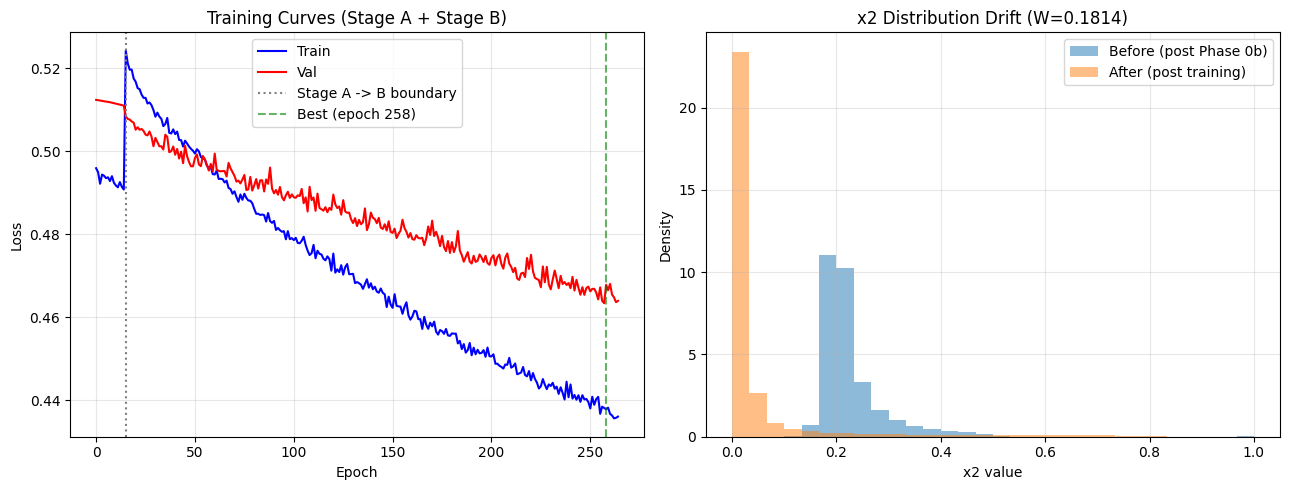

In [20]:
def set_trainable(params, trainable: bool):
    for p in params:
        p.requires_grad = trainable

def set_bn_eval(module):
    for m in module.modules():
        if isinstance(m, nn.BatchNorm2d):
            m.eval()

def set_bn_train(module):
    for m in module.modules():
        if isinstance(m, nn.BatchNorm2d):
            m.train()

encoder_modules = [model.enc1, model.enc2, model.enc3, model.enc4, model.bot]
decoder_modules = [model.smoe2, model.smoe3, model.smoe4,
                   model.up4, model.dec4, model.up3, model.dec3,
                   model.up2, model.dec2, model.up1, model.dec1, model.unet_head]


def train_one_epoch_stageA(model, loader, optimizer, criterion, device):
    model.train()
    for m in encoder_modules + decoder_modules:
        set_bn_eval(m)
    running = 0.0
    for imgs, masks, _ in tqdm(loader, desc='  StageA train', leave=False):
        imgs, masks = imgs.to(device, non_blocking=True), masks.to(device, non_blocking=True)
        optimizer.zero_grad()
        prob, wbar, _, _, _, _ = model(imgs)
        if prob.dim() == 3: prob = prob.unsqueeze(1)
        loss = criterion(prob, masks)
        if RULE_DIVERSITY_BETA > 0:                      # off by default (0.0) -- no-op
            div_term = (rule_balance_loss_edge_weighted(wbar, masks) if RULE_DIVERSITY_EDGE_WEIGHTED
                        else rule_balance_loss(wbar))
            loss = loss - RULE_DIVERSITY_BETA * div_term
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP_NORM)
        optimizer.step()
        running += loss.item()
    return running / len(loader)


def train_one_epoch_stageB(model, loader, optimizer, criterion, device, alpha, encoder_frozen):
    model.train()
    if encoder_frozen:
        for m in encoder_modules:
            set_bn_eval(m)
    else:
        for m in encoder_modules:
            set_bn_train(m)
    for m in decoder_modules:
        set_bn_train(m)

    running = 0.0
    for imgs, masks, _ in tqdm(loader, desc='  StageB train', leave=False):
        imgs, masks = imgs.to(device, non_blocking=True), masks.to(device, non_blocking=True)
        optimizer.zero_grad()
        prob, wbar, x2, _, unet_logits, _ = model(imgs)
        if prob.dim() == 3: prob = prob.unsqueeze(1)
        l_backbone = criterion(torch.sigmoid(unet_logits), masks)
        l_anfis    = criterion(prob, masks)
        loss = alpha * l_backbone + (1 - alpha) * l_anfis
        if RULE_DIVERSITY_BETA > 0:                      # off by default (0.0) -- no-op
            div_term = (rule_balance_loss_edge_weighted(wbar, masks) if RULE_DIVERSITY_EDGE_WEIGHTED
                        else rule_balance_loss(wbar))
            loss = loss - RULE_DIVERSITY_BETA * div_term
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP_NORM)
        optimizer.step()
        running += loss.item()
    return running / len(loader)


def validate_epoch(model, loader, criterion, device):
    model.eval()
    running = 0.0
    with torch.no_grad():
        for imgs, masks, _ in tqdm(loader, desc='  val', leave=False):
            masks = masks.to(device, non_blocking=True)
            pred  = predict_native(model, imgs, device, which='anfis')
            running += criterion(pred, masks).item()
    return running / len(loader)


@torch.no_grad()
def print_rule_diagnostics(model, loader, device, n_batches=15, tag=''):
    wbars = []
    gts = []
    model.eval()
    for i, (imgs, masks, _) in enumerate(loader):
        if i >= n_batches: break
        imgs_pad, H, W = pad_to_multiple(imgs.to(device), multiple=PAD_MULTIPLE)
        _, wbar, _, _, _, _ = model(imgs_pad)
        wbars.append(wbar[..., :H, :W].cpu())
        gts.append(masks.cpu())
    mean_w, max_w, dom_pct = rule_activation_diagnostics(wbars)
    print(f'  [rule diagnostics{tag}] ' +
          '  '.join(f'R{k+1}: fire={mean_w[k]:.2f} dom={dom_pct[k]:.0f}%' for k in range(len(mean_w))))
    if dom_pct.max() > 95:
        print('    WARNING: possible rule collapse (one rule >95% dominant).')
    # FIX: class-conditioned breakdown -- tells apart genuine collapse from the
    # expected effect of BSDS500's natural class imbalance (see cell 12 docstring).
    dom_edge_pct, dom_nonedge_pct, n_edge, n_nonedge = rule_activation_diagnostics_by_class(wbars, gts)
    print(f'  [rule diagnostics{tag}, class-conditioned] ' +
          '  '.join(f'R{k+1}: edge={dom_edge_pct[k]:.0f}% nonedge={dom_nonedge_pct[k]:.0f}%' for k in range(len(dom_edge_pct))))
    if dom_edge_pct.max() > 95:
        print('    WARNING: one rule dominates even within GT-edge pixels -- this is genuine collapse, not class imbalance.')


train_losses, val_losses = [], []
best_val_loss, best_epoch = float('inf'), 0
best_state_dict = None   # kept IN MEMORY only -- no disk checkpoint, no Kaggle auto-save

# ---------------------------------------------------------------------------
# STAGE A -- frozen baseline
# ---------------------------------------------------------------------------
print('='*72)
print(f'STAGE A -- genuinely frozen backbone baseline ({FROZEN_BASELINE_EPOCHS} epochs)')
print('='*72)
set_trainable(encoder_params, False)
set_trainable(decoder_params, False)
set_trainable(anfis_params,   True)
set_trainable(mf_params,      True)

for epoch in range(1, FROZEN_BASELINE_EPOCHS + 1):
    tl = train_one_epoch_stageA(model, loader_train, optimizer, criterion, DEVICE)
    vl = validate_epoch(model, loader_val, criterion, DEVICE)
    train_losses.append(tl); val_losses.append(vl)
    print(f'  [StageA] epoch {epoch:3d}/{FROZEN_BASELINE_EPOCHS}  train={tl:.4f}  val={vl:.4f}')
    if vl < best_val_loss:
        best_val_loss, best_epoch = vl, epoch
        best_state_dict = copy.deepcopy(model.state_dict())   # in-memory only

print(f'\nStage A complete. Best val loss so far: {best_val_loss:.4f}')

# ---------------------------------------------------------------------------
# STAGE B -- joint fine-tuning, gradual unfreeze
# ---------------------------------------------------------------------------
print('\n' + '='*72)
print(f'STAGE B -- joint fine-tuning, up to {MAX_EPOCHS} epochs, gradual unfreeze')
print('='*72)
set_trainable(decoder_params, True)
set_trainable(anfis_params,   True)
patience_ctr = 0

for epoch in range(1, MAX_EPOCHS + 1):
    mf_frozen = epoch <= MF_FREEZE_EPOCHS
    set_trainable(mf_params, not mf_frozen)

    encoder_frozen = epoch <= ENCODER_UNFREEZE_EPOCH
    set_trainable(encoder_params, not encoder_frozen)

    if epoch == 1:
        print(f'  MF params frozen for Stage-B epochs 1-{MF_FREEZE_EPOCHS}')
        print(f'  Encoder frozen (weights+BN) for Stage-B epochs 1-{ENCODER_UNFREEZE_EPOCH}, '
              f'then unfreezes at lr={LR_ENCODER}')
    if epoch == ENCODER_UNFREEZE_EPOCH + 1:
        print(f'  >>> Encoder unfrozen at Stage-B epoch {epoch} (lr={LR_ENCODER})')

    tl = train_one_epoch_stageB(model, loader_train, optimizer, criterion, DEVICE,
                                ALPHA_BACKBONE, encoder_frozen)
    vl = validate_epoch(model, loader_val, criterion, DEVICE)
    train_losses.append(tl); val_losses.append(vl)
    scheduler.step(vl)

    if vl < best_val_loss:
        best_val_loss, best_epoch, patience_ctr = vl, len(train_losses), 0
        best_state_dict = copy.deepcopy(model.state_dict())   # in-memory only
        status = 'BEST'
    else:
        patience_ctr += 1
        status = f'pat {patience_ctr}/{PATIENCE}'

    if epoch % 10 == 0 or epoch == 1:
        lrs = [f'{g["name"]}={g["lr"]:.1e}' for g in optimizer.param_groups]
        print(f'  [StageB] epoch {epoch:4d} train={tl:.4f} val={vl:.4f} {" ".join(lrs)}  {status}')

    if epoch % RULE_DIAG_EVERY_N_EPOCHS == 0:
        print_rule_diagnostics(model, loader_val, DEVICE, tag=f' @ StageB epoch {epoch}')

    if patience_ctr >= PATIENCE:
        print(f'\nEarly stopping at Stage-B epoch {epoch}')
        break

# Restore best weights (in-memory swap, nothing written to disk)
if best_state_dict is not None:
    model.load_state_dict(best_state_dict)
print(f'\nBest val loss: {best_val_loss:.4f} at global epoch {best_epoch} (best weights restored from memory)')

# Feature-drift snapshot AFTER training (compare against the Phase-0b baseline)
with torch.no_grad():
    x2_after_list = []
    for i, (imgs, _, _) in enumerate(loader_val):
        if i >= FEATURE_DRIFT_N_BATCHES: break
        imgs_pad, H, W = pad_to_multiple(imgs.to(DEVICE), multiple=PAD_MULTIPLE)
        _, _, x2_map, _, _, _ = model(imgs_pad)
        x2_after_list.append(x2_map[..., :H, :W].cpu().flatten())
x2_dist_after = torch.cat(x2_after_list).numpy()

w_dist = wasserstein_distance(x2_dist_before, x2_dist_after)
hist_before, edges = np.histogram(x2_dist_before, bins=30, range=(0,1), density=True)
hist_after, _      = np.histogram(x2_dist_after,  bins=edges, density=True)
kl = float(np.sum(np.where(hist_before > 0,
                           hist_before * np.log((hist_before + 1e-8) / (hist_after + 1e-8)), 0)) * (edges[1]-edges[0]))

print('\n' + '='*72)
print('FEATURE-DRIFT REPORT -- x2 = sigmoid(unet_logits), before vs after backbone fine-tuning')
print('='*72)
print(f'  Before (post Phase-0b) : mean={x2_dist_before.mean():.4f}  std={x2_dist_before.std():.4f}')
print(f'  After  (post training) : mean={x2_dist_after.mean():.4f}  std={x2_dist_after.std():.4f}')
print(f'  Wasserstein distance   : {w_dist:.4f}')
print(f'  Approx. KL(before||after): {kl:.4f}')
if w_dist > 0.05:
    print('  NOTE: noticeable drift -- the FCM rule geometry was fit on a feature')
    print('  space that has since moved; consider a smaller LR_ENCODER or an')
    print('  earlier ENCODER_UNFREEZE_EPOCH if downstream metrics look off.')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(train_losses, 'b-', lw=1.5, label='Train')
axes[0].plot(val_losses,   'r-', lw=1.5, label='Val')
axes[0].axvline(FROZEN_BASELINE_EPOCHS, color='gray', ls=':', label='Stage A -> B boundary')
axes[0].axvline(best_epoch, color='g', ls='--', alpha=0.6, label=f'Best (epoch {best_epoch})')
axes[0].set(xlabel='Epoch', ylabel='Loss', title='Training Curves (Stage A + Stage B)')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].hist(x2_dist_before, bins=30, range=(0,1), alpha=0.5, label='Before (post Phase 0b)', density=True)
axes[1].hist(x2_dist_after,  bins=30, range=(0,1), alpha=0.5, label='After (post training)', density=True)
axes[1].set(xlabel='x2 value', ylabel='Density', title=f'x2 Distribution Drift (W={w_dist:.4f})')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/training_curves_and_drift.png', dpi=150)
plt.show()


## Cell — Evaluation: ODS / OIS / AP (official protocol)
### Now evaluates BOTH the ANFIS head and the raw backbone (`P_backbone` vs
### `P_ANFIS`), so the direct-GT-training claim can be checked empirically.


Computing metrics on test set (ANFIS head)...


Matching (anfis): 100%|██████████| 200/200 [1:47:42<00:00, 32.31s/it]  


ANFIS    ODS=0.7790  OIS=0.7729  AP=0.6735  best_t=0.010

Computing metrics on test set (raw backbone, P_backbone = sigmoid(unet_logits))...


Matching (backbone): 100%|██████████| 200/200 [2:23:00<00:00, 42.90s/it]   


Backbone ODS=0.7982  OIS=0.7884  AP=0.6707  best_t=0.010


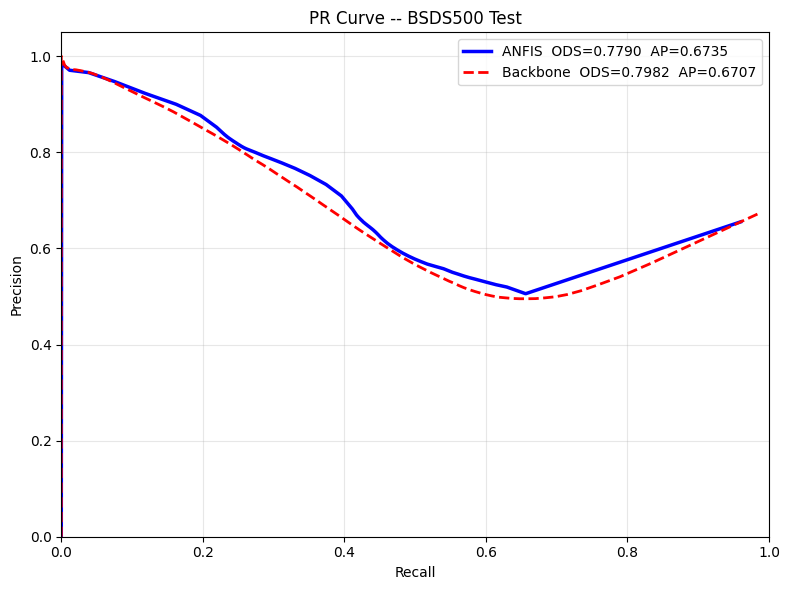

In [21]:
from scipy.optimize import linear_sum_assignment
from scipy.spatial  import cKDTree
from scipy.sparse   import coo_matrix
from scipy.sparse.csgraph import connected_components
import glob, concurrent.futures

N_WORKERS = min(os.cpu_count() or 4, 4)
MAX_PRED  = 15000

def load_gt_boundaries(mat_path):
    boundaries = []
    try:
        mat = scipy.io.loadmat(mat_path, squeeze_me=True)
        gt_cell = mat['groundTruth']
        if gt_cell.ndim == 0:
            gt_cell = gt_cell.reshape(1)
        for ann in gt_cell.flat:
            try:
                b = ann['Boundaries'] if isinstance(ann, np.void) else ann[()]['Boundaries']
            except (KeyError, TypeError, IndexError):
                b = ann[0, 0][1] if hasattr(ann, '__getitem__') else ann.Boundaries
            if hasattr(b, 'toarray'):
                b = b.toarray()
            boundaries.append(b.astype(np.float32))
        return boundaries
    except Exception:
        return []


def _sparse_bipartite_tp(pred_yx, gt_yx, gt_tree, maxDist):
    n_pred = len(pred_yx); n_gt = len(gt_yx)
    if n_pred == 0 or n_gt == 0:
        return 0.0
    neighbors = gt_tree.query_ball_point(pred_yx, r=maxDist)
    pred_idx_list, gt_idx_list, dist_list = [], [], []
    for pi, gts in enumerate(neighbors):
        if not gts: continue
        gy = gt_yx[gts]
        d  = np.sqrt(((gy - pred_yx[pi]) ** 2).sum(-1))
        for gj, dd in zip(gts, d):
            pred_idx_list.append(pi); gt_idx_list.append(gj); dist_list.append(dd)
    if not pred_idx_list:
        return 0.0
    pred_idx_arr = np.array(pred_idx_list); gt_idx_arr = np.array(gt_idx_list)
    dist_arr = np.array(dist_list)
    n_total = n_pred + n_gt
    rows = np.concatenate([pred_idx_arr, gt_idx_arr + n_pred])
    cols = np.concatenate([gt_idx_arr + n_pred, pred_idx_arr])
    data = np.ones(len(rows))
    graph = coo_matrix((data, (rows, cols)), shape=(n_total, n_total))
    _, labels = connected_components(graph, directed=False)
    pred_labels = labels[:n_pred]
    edge_comp = pred_labels[pred_idx_arr]
    tp = 0.0
    for comp_id in np.unique(edge_comp):
        mask = edge_comp == comp_id
        p_local_ids = np.unique(pred_idx_arr[mask]); g_local_ids = np.unique(gt_idx_arr[mask])
        p_map = {p: k for k, p in enumerate(p_local_ids)}
        g_map = {g: k for k, g in enumerate(g_local_ids)}
        r, c = len(p_local_ids), len(g_local_ids)
        cost = np.full((r, c), 1e9)
        for p, g, d in zip(pred_idx_arr[mask], gt_idx_arr[mask], dist_arr[mask]):
            cost[p_map[p], g_map[g]] = d
        row_ind, col_ind = linear_sum_assignment(cost)
        valid = cost[row_ind, col_ind] < maxDist
        tp += float(valid.sum())
    return tp


def bipartite_counts_at_thresholds(prob, gt_boundaries, thresholds):
    H, W = prob.shape
    maxDist = max(0.0075 * max(H, W), 1.0)
    n_thresh = len(thresholds)
    gt_stack = np.stack(gt_boundaries, axis=0)
    gt_union = (gt_stack.max(axis=0) > 0.5).astype(bool)
    n_gt = int(gt_union.sum())
    tp_arr = np.zeros(n_thresh); fp_arr = np.zeros(n_thresh); fn_arr = np.zeros(n_thresh)
    if n_gt == 0:
        for i, t in enumerate(thresholds):
            fp_arr[i] = float((prob >= t).sum())
        return tp_arr, fp_arr, fn_arr
    gt_yx = np.column_stack(np.where(gt_union)).astype(np.float32)
    gt_tree = cKDTree(gt_yx)
    for i, t in enumerate(thresholds):
        pred_edge = (prob >= t)
        if not pred_edge.any():
            fn_arr[i] = float(n_gt); continue
        pred_yx = np.column_stack(np.where(pred_edge)).astype(np.float32)
        if len(pred_yx) > MAX_PRED:
            dists_all, _ = gt_tree.query(pred_yx)
            keep_idx = np.argsort(dists_all)[:MAX_PRED]
            pred_yx = pred_yx[keep_idx]
        n_pred = len(pred_yx)
        tp = _sparse_bipartite_tp(pred_yx, gt_yx, gt_tree, maxDist)
        fp_arr[i] = float(n_pred) - tp
        fn_arr[i] = float(n_gt) - tp
        tp_arr[i] = tp
    return tp_arr, fp_arr, fn_arr


def _image_counts_worker(args):
    prob, mat_path, gt_fallback, thresholds = args
    if mat_path and os.path.exists(mat_path):
        gt_bnd = load_gt_boundaries(mat_path)
    else:
        gt_bnd = None
    if not gt_bnd:
        gt_bnd = [gt_fallback]
    return bipartite_counts_at_thresholds(prob, gt_bnd, thresholds)


def compute_unified_metrics(model, loader, device, n_thresh=99, which='anfis'):
    model.eval()
    thresholds = np.linspace(0.01, 0.99, n_thresh)
    gt_dir = os.path.join(BSR_ROOT, 'data', 'groundTruth', 'test')
    job_args = []
    with torch.no_grad():
        for imgs, masks, stems in tqdm(loader, desc=f'Inference ({which})'):
            pred = predict_native(model, imgs, device, which=which)
            prob = pred.squeeze().cpu().numpy()
            gt_b = (masks.squeeze().cpu().numpy() > 0.5).astype(np.float32)
            stem = stems[0] if isinstance(stems, (list, tuple)) else stems
            mat_path = os.path.join(gt_dir, f'{stem}.mat')
            job_args.append((prob, mat_path, gt_b, thresholds))

    with concurrent.futures.ThreadPoolExecutor(max_workers=N_WORKERS) as ex:
        per_image_counts = list(tqdm(ex.map(_image_counts_worker, job_args),
                                     total=len(job_args), desc=f'Matching ({which})'))

    all_tp = np.zeros(n_thresh); all_fp = np.zeros(n_thresh); all_fn = np.zeros(n_thresh)
    for tp_arr, fp_arr, fn_arr in per_image_counts:
        all_tp += tp_arr; all_fp += fp_arr; all_fn += fn_arr
    precs = all_tp / (all_tp + all_fp + 1e-8)
    recs  = all_tp / (all_tp + all_fn + 1e-8)
    fscs  = 2 * precs * recs / (precs + recs + 1e-8)
    best_i = int(np.argmax(fscs))
    ODS = float(fscs[best_i]); best_t = float(thresholds[best_i])

    per_image_best_f = []
    for tp_arr, fp_arr, fn_arr in per_image_counts:
        p_i = tp_arr / (tp_arr + fp_arr + 1e-8); r_i = tp_arr / (tp_arr + fn_arr + 1e-8)
        f_i = 2 * p_i * r_i / (p_i + r_i + 1e-8)
        per_image_best_f.append(float(f_i.max()))
    OIS = float(np.mean(per_image_best_f))

    per_image_ap = []
    for tp_arr, fp_arr, fn_arr in per_image_counts:
        p_i = tp_arr / (tp_arr + fp_arr + 1e-8); r_i = tp_arr / (tp_arr + fn_arr + 1e-8)
        order = np.argsort(r_i)
        try:
            per_image_ap.append(float(auc(r_i[order], p_i[order])))
        except ValueError:
            continue
    AP = float(np.mean(per_image_ap)) if per_image_ap else 0.0
    return ODS, OIS, AP, precs, recs, best_t


print('Computing metrics on test set (ANFIS head)...')
ODS, OIS, AP, precs, recs, best_t = compute_unified_metrics(model, loader_test, DEVICE, which='anfis')
print(f'ANFIS    ODS={ODS:.4f}  OIS={OIS:.4f}  AP={AP:.4f}  best_t={best_t:.3f}')

ODS_bb = OIS_bb = AP_bb = None
if EVALUATE_BACKBONE_BASELINE:
    print('\nComputing metrics on test set (raw backbone, P_backbone = sigmoid(unet_logits))...')
    ODS_bb, OIS_bb, AP_bb, precs_bb, recs_bb, best_t_bb = compute_unified_metrics(
        model, loader_test, DEVICE, which='backbone')
    print(f'Backbone ODS={ODS_bb:.4f}  OIS={OIS_bb:.4f}  AP={AP_bb:.4f}  best_t={best_t_bb:.3f}')

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(recs, precs, 'b-', lw=2.5, label=f'ANFIS  ODS={ODS:.4f}  AP={AP:.4f}')
if EVALUATE_BACKBONE_BASELINE:
    ax.plot(recs_bb, precs_bb, 'r--', lw=2, label=f'Backbone  ODS={ODS_bb:.4f}  AP={AP_bb:.4f}')
ax.set(xlabel='Recall', ylabel='Precision', title='PR Curve -- BSDS500 Test',
       xlim=[0,1], ylim=[0,1.05])
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/pr_curve.png', dpi=150)
plt.show()


## Cell — Metric Comparison Table (paper baseline vs backbone-this-run vs ANFIS-this-run)

In [22]:
print('='*76)
print('  COMPARISON: Paper-Reported Baseline vs This Run (Backbone and ANFIS)')
print('='*76)
paper_ods, paper_ois, paper_ap = 0.7628, 0.7458, 0.7222
print(f'  {"Metric":<10} {"Paper Table 1":>16} {"Backbone (this run)":>20} {"ANFIS (this run)":>18}')
print('-'*76)
for name, paper_v, bb_v, anfis_v in [('ODS', paper_ods, ODS_bb, ODS),
                                      ('OIS', paper_ois, OIS_bb, OIS),
                                      ('AP',  paper_ap,  AP_bb,  AP)]:
    bb_str = f'{bb_v:.4f}' if bb_v is not None else 'n/a'
    print(f'  {name:<10} {paper_v:>16.4f} {bb_str:>20} {anfis_v:>18.4f}')
print('-'*76)
if ODS_bb is not None:
    print(f'  ANFIS vs Backbone gain (this run): ODS {ODS-ODS_bb:+.4f}  OIS {OIS-OIS_bb:+.4f}  AP {AP-AP_bb:+.4f}')
    print('  (This is the direct empirical evidence for the direct-GT-training claim --')
    print('   ANFIS is trained against ground truth, not distilled from the backbone,')
    print('   so it should be able to exceed backbone-only performance.)')
print('='*76)


  COMPARISON: Paper-Reported Baseline vs This Run (Backbone and ANFIS)
  Metric        Paper Table 1  Backbone (this run)   ANFIS (this run)
----------------------------------------------------------------------------
  ODS                  0.7628               0.7982             0.7790
  OIS                  0.7458               0.7884             0.7729
  AP                   0.7222               0.6707             0.6735
----------------------------------------------------------------------------
  ANFIS vs Backbone gain (this run): ODS -0.0192  OIS -0.0156  AP +0.0027
  (This is the direct empirical evidence for the direct-GT-training claim --
   ANFIS is trained against ground truth, not distilled from the backbone,
   so it should be able to exceed backbone-only performance.)


## Cell — Qualitative Results (unchanged)

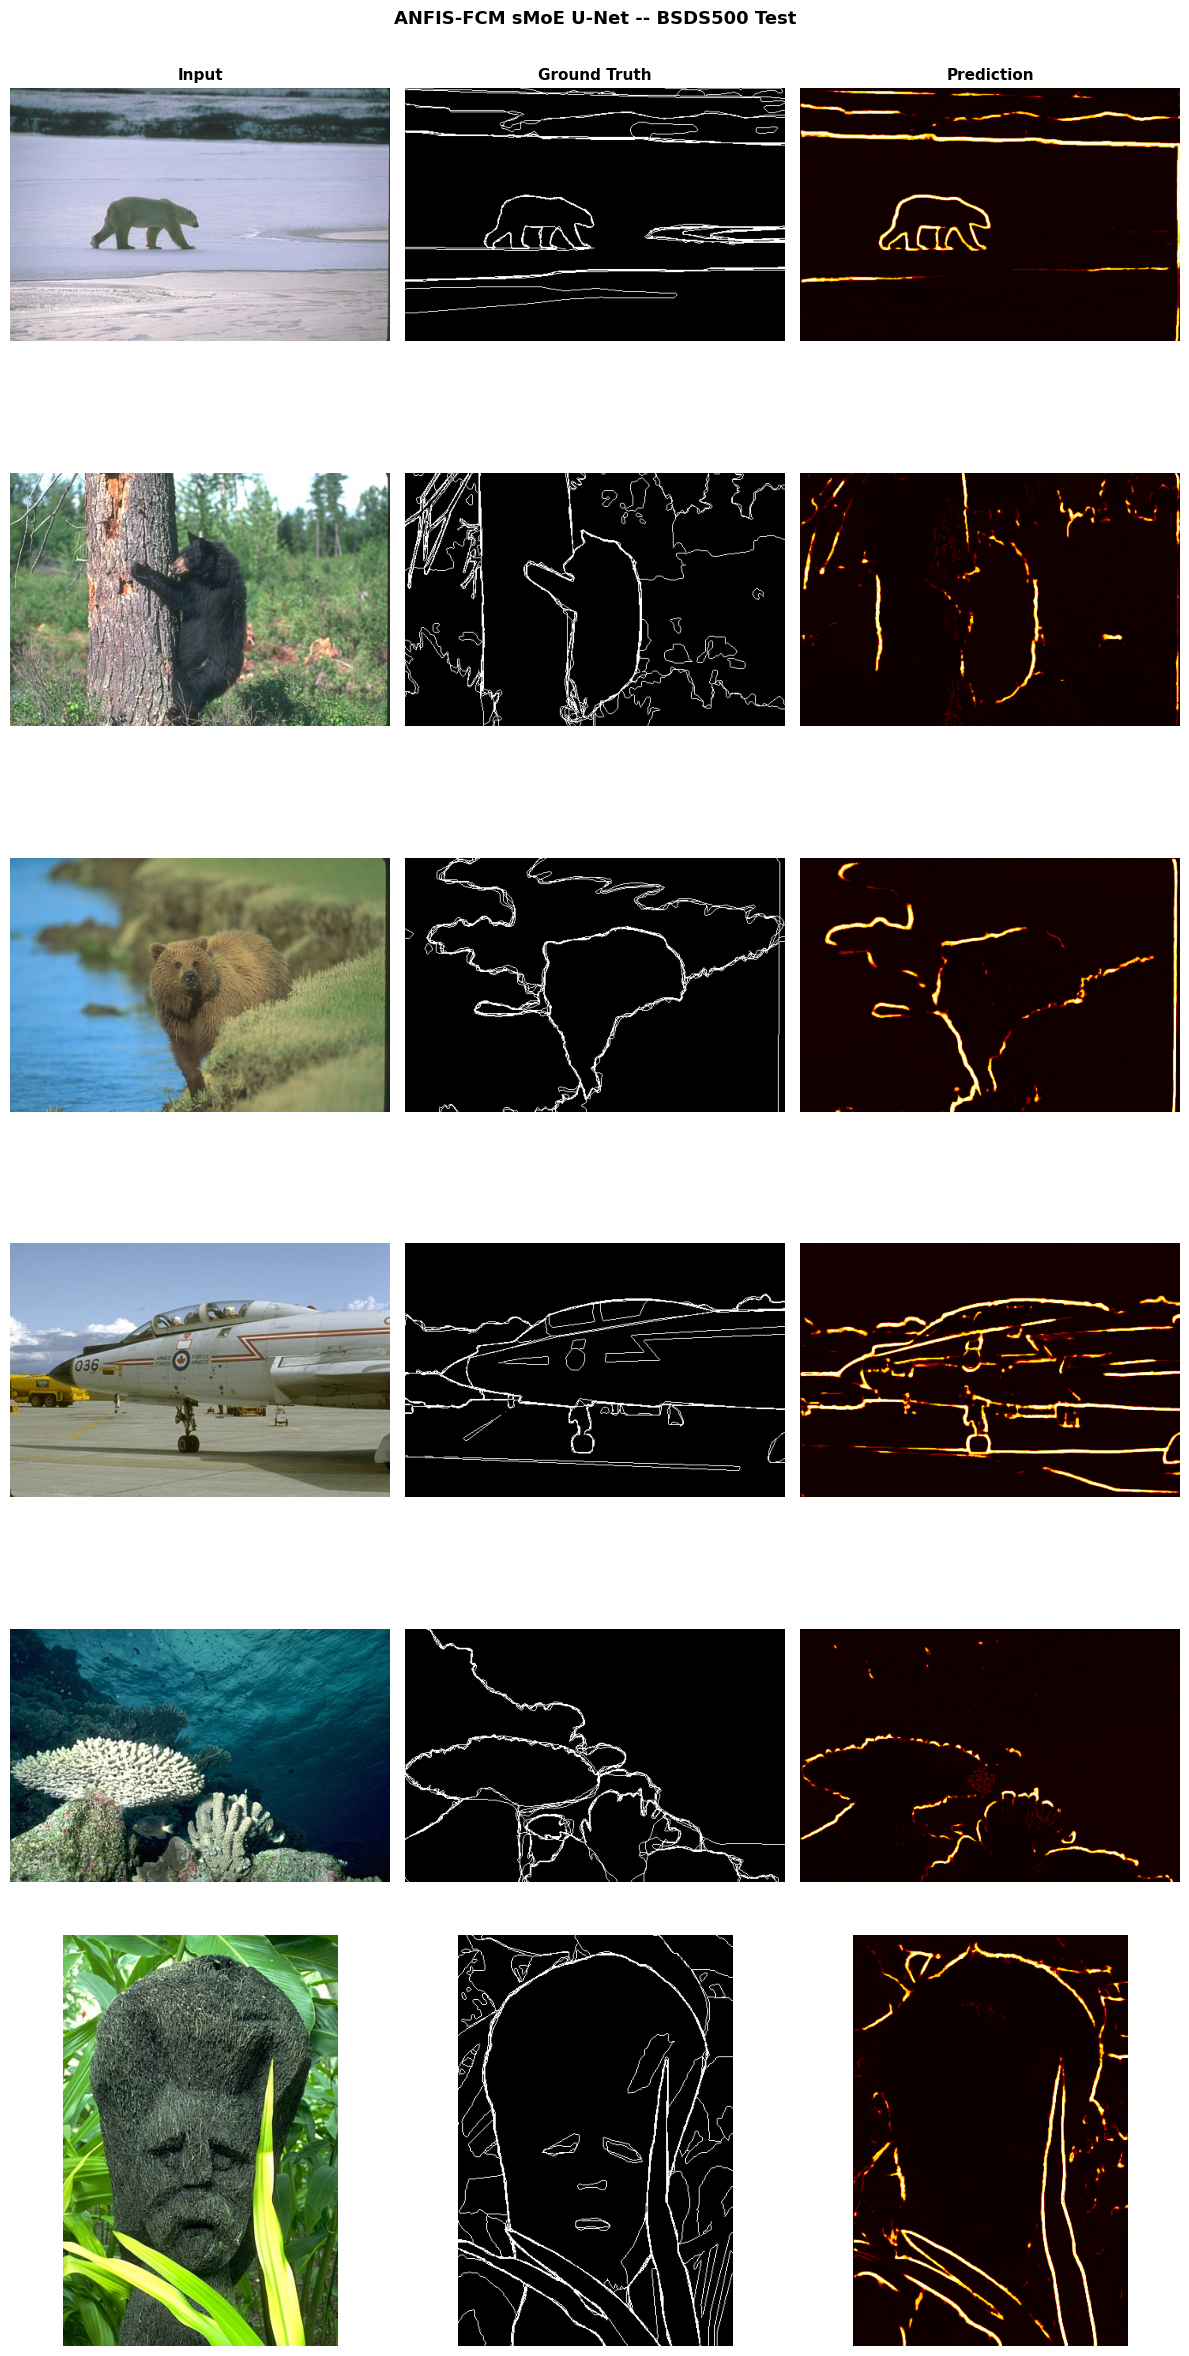

In [23]:
def denorm(t):
    mean = torch.tensor([0.485,0.456,0.406], device=t.device).view(3,1,1)
    std  = torch.tensor([0.229,0.224,0.225], device=t.device).view(3,1,1)
    return (t*std+mean).clamp(0,1).permute(1,2,0).cpu().numpy()

model.eval()
N = min(6, len(ds_test))
samples = []
with torch.no_grad():
    for i, (img, mask, stem) in enumerate(loader_test):
        if i >= N: break
        pred = predict_native(model, img, DEVICE, which='anfis')
        if pred.dim() == 3: pred = pred.unsqueeze(1)
        samples.append((img.cpu(), mask.cpu(), pred.cpu(), stem[0]))

fig, axes = plt.subplots(N, 3, figsize=(12, 4*N))
titles = ['Input', 'Ground Truth', 'Prediction']
fig.suptitle('ANFIS-FCM sMoE U-Net -- BSDS500 Test', fontsize=13, fontweight='bold')
for row, (img, mask, pred, stem) in enumerate(samples):
    axes[row,0].imshow(denorm(img[0]))
    axes[row,1].imshow(mask[0,0].numpy(), cmap='gray')
    axes[row,2].imshow(pred[0,0].numpy(), cmap='hot')
    for col in range(3):
        axes[row,col].axis('off')
        if row == 0:
            axes[row,col].set_title(titles[col], fontsize=11, fontweight='bold')
    axes[row,0].set_ylabel(stem, fontsize=8, rotation=0, labelpad=60)
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/qualitative_results.png', dpi=150, bbox_inches='tight')
plt.show()


## Cell — ANFIS Rule Firing Maps + Entropy Map (R*, native XAI)

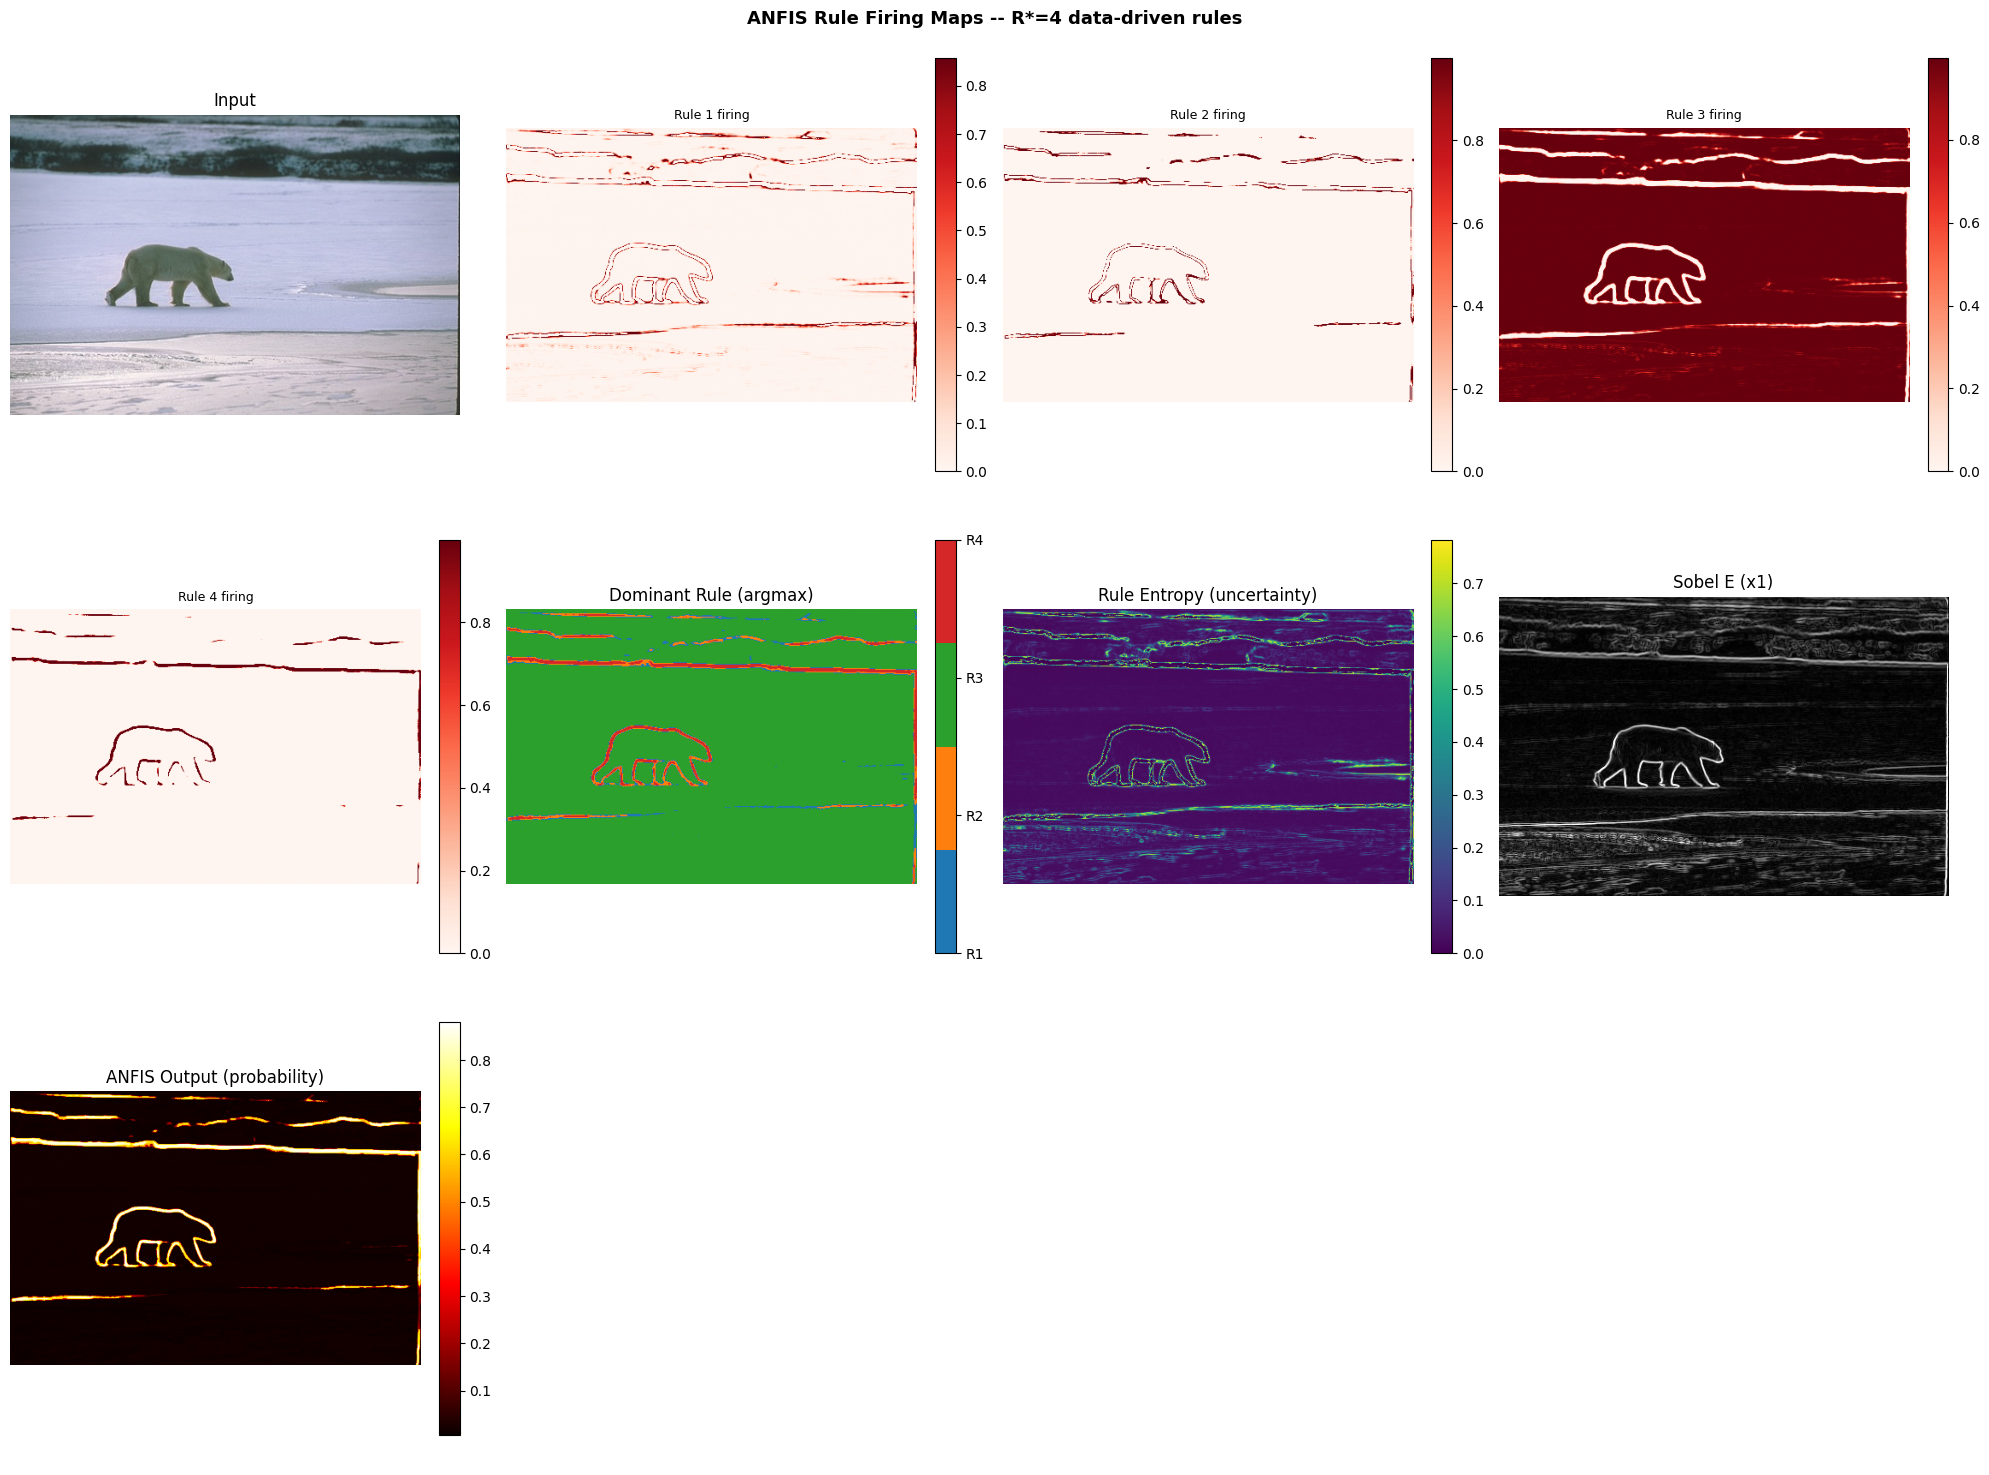

ANFIS rule firing maps + entropy map saved (R*=4 rules)


In [24]:
model.eval()
_imgs, _masks, _stems = next(iter(loader_test))
_imgs_pad, H0, W0 = pad_to_multiple(_imgs.to(DEVICE), multiple=PAD_MULTIPLE)

with torch.no_grad():
    out = model(_imgs_pad)

prob, rule_maps, x2_map, edge_sig, _, x1_map = out
prob      = prob[..., :H0, :W0]
rule_maps = rule_maps[..., :H0, :W0]
edge_sig  = edge_sig[..., :H0, :W0]
x1_map    = x1_map[..., :H0, :W0]
x2_map    = x2_map[..., :H0, :W0]

img_disp  = denorm(_imgs[0])
pred_disp = prob[0].cpu().numpy()
if pred_disp.ndim == 3 and pred_disp.shape[0] == 1:
    pred_disp = pred_disp.squeeze(0)
edge_disp = edge_sig[0,0].cpu().numpy()
rw        = rule_maps[0].cpu()
R         = rw.shape[0]
entropy_map = rule_entropy_map(rule_maps)[0,0].cpu().numpy()   # new: uncertainty map

n_panels = R + 5
n_cols   = 4
n_rows   = int(np.ceil(n_panels / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 5*n_rows))
axes = np.array(axes).reshape(-1)
fig.suptitle(f'ANFIS Rule Firing Maps -- R*={R} data-driven rules', fontsize=13, fontweight='bold')

axes[0].imshow(img_disp); axes[0].set_title('Input'); axes[0].axis('off')

cmap_cycle = plt.cm.tab10(np.linspace(0, 1, max(R, 10)))
for k in range(R):
    ax = axes[k+1]
    rmap = rw[k].numpy()
    vmax = max(float(np.percentile(rmap, 99)), 1e-3)
    im = ax.imshow(rmap, cmap='Reds', vmin=0, vmax=vmax)
    ax.set_title(f'Rule {k+1} firing', fontsize=9); ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

dom = rw.argmax(dim=0).numpy()
ax_dom = axes[R+1]
cmap_dom = ListedColormap([cmap_cycle[k] for k in range(R)])
im_dom = ax_dom.imshow(dom, cmap=cmap_dom, vmin=0, vmax=R-1)
ax_dom.set_title('Dominant Rule (argmax)'); ax_dom.axis('off')
cbar = plt.colorbar(im_dom, ax=ax_dom, fraction=0.046, pad=0.04, ticks=range(R))
cbar.set_ticklabels([f'R{k+1}' for k in range(R)])

im_ent = axes[R+2].imshow(entropy_map, cmap='viridis')
axes[R+2].set_title('Rule Entropy (uncertainty)'); axes[R+2].axis('off')
plt.colorbar(im_ent, ax=axes[R+2], fraction=0.046, pad=0.04)

axes[R+3].imshow(edge_disp, cmap='gray')
axes[R+3].set_title('Sobel E (x1)'); axes[R+3].axis('off')

im_out = axes[R+4].imshow(pred_disp, cmap='hot')
axes[R+4].set_title('ANFIS Output (probability)'); axes[R+4].axis('off')
plt.colorbar(im_out, ax=axes[R+4], fraction=0.046, pad=0.04)

for ax in axes[n_panels:]:
    ax.axis('off')

plt.tight_layout()
plt.savefig(f'{WORK_DIR}/rule_firing_maps.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'ANFIS rule firing maps + entropy map saved (R*={R} rules)')


## Cell — Rule Contribution Maps
Distinct from firing maps: a rule can fire strongly (`wbar` high) yet
contribute negatively to the final prediction if its consequent `(p,q,r)` is
negative -- e.g. actively suppressing a false texture edge. Firing alone
can't show that; contribution `wbar_i * TSK_i(x)` can.


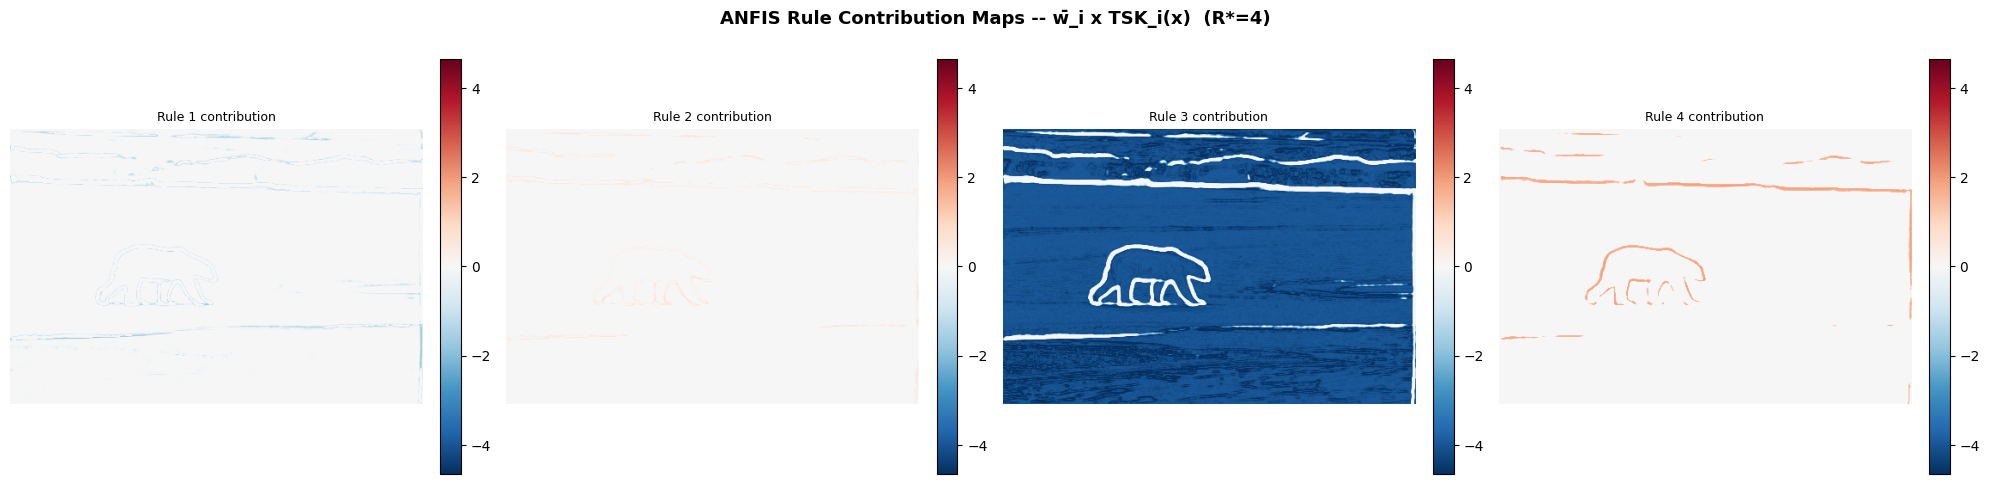

Rule contribution maps saved -- blue/red indicate suppressing/reinforcing contribution


In [25]:
contrib = rule_contribution_maps(model.anfis_head, x1_map, x2_map, rule_maps)[0].cpu()  # [R,H,W]
vmax_c = float(np.percentile(np.abs(contrib.numpy()), 99)) or 1e-3

n_cols = 4
n_rows = int(np.ceil(R / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 5*n_rows))
axes = np.array(axes).reshape(-1)
fig.suptitle(f'ANFIS Rule Contribution Maps -- w̄_i x TSK_i(x)  (R*={R})', fontsize=13, fontweight='bold')
for k in range(R):
    im = axes[k].imshow(contrib[k].numpy(), cmap='RdBu_r', vmin=-vmax_c, vmax=vmax_c)
    axes[k].set_title(f'Rule {k+1} contribution', fontsize=9); axes[k].axis('off')
    plt.colorbar(im, ax=axes[k], fraction=0.046, pad=0.04)
for ax in axes[R:]:
    ax.axis('off')
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/rule_contribution_maps.png', dpi=150, bbox_inches='tight')
plt.show()
print('Rule contribution maps saved -- blue/red indicate suppressing/reinforcing contribution')


## Cell — Rule Semantic Profiling Table
For each rule: mean x1, mean x2, mean GT edge probability, mean predicted
probability where that rule dominates, and a plain-language interpretation --
much more informative than a firing heatmap alone.


In [26]:
print('Computing rule semantic profile over the test set (dominant-rule pixels only)...')
sums = {k: {'x1':0.0,'x2':0.0,'gt':0.0,'pred':0.0,'n':0} for k in range(R)}
model.eval()
with torch.no_grad():
    for imgs, masks, _ in tqdm(loader_test, desc='  profiling'):
        imgs_pad, H, W = pad_to_multiple(imgs.to(DEVICE), multiple=PAD_MULTIPLE)
        prob_t, wbar_t, x2_t, _, _, x1_t = model(imgs_pad)
        prob_t = prob_t[..., :H, :W]; wbar_t = wbar_t[..., :H, :W]
        x1_t = x1_t[..., :H, :W]; x2_t = x2_t[..., :H, :W]
        gt_t = F.interpolate(masks.to(DEVICE), size=(H, W), mode='nearest')
        dom_t = wbar_t.argmax(dim=1)
        for k in range(R):
            mask_k = (dom_t == k)
            if mask_k.sum() == 0: continue
            sums[k]['x1']   += x1_t[:,0][mask_k].sum().item()
            sums[k]['x2']   += x2_t[:,0][mask_k].sum().item()
            sums[k]['gt']   += gt_t[:,0][mask_k].sum().item()
            sums[k]['pred'] += prob_t.squeeze(1)[mask_k].sum().item()
            sums[k]['n']    += mask_k.sum().item()

def _interp(x1_lvl, x2_lvl):
    if x1_lvl == 'Low'  and x2_lvl == 'Low':  return 'Smooth background'
    if x1_lvl == 'High' and x2_lvl == 'Low':  return 'Texture / false edge'
    if x1_lvl == 'Low'  and x2_lvl == 'High': return 'Semantic boundary'
    return 'Strong true edge'

print(f'\n  {"Rule":<6} {"mean x1":>9} {"mean x2":>9} {"mean GT":>9} {"mean pred":>10} {"x1":>6} {"x2":>6}  Interpretation')
print('  ' + '-'*84)
for k in range(R):
    n = max(sums[k]['n'], 1)
    mx1, mx2 = sums[k]['x1']/n, sums[k]['x2']/n
    mgt, mpr = sums[k]['gt']/n, sums[k]['pred']/n
    x1_lvl = 'High' if mx1 > 0.5 else 'Low'
    x2_lvl = 'High' if mx2 > 0.5 else 'Low'
    interp = _interp(x1_lvl, x2_lvl)
    print(f'  R{k+1:<5} {mx1:>9.3f} {mx2:>9.3f} {mgt:>9.3f} {mpr:>10.3f} {x1_lvl:>6} {x2_lvl:>6}  {interp}')


Computing rule semantic profile over the test set (dominant-rule pixels only)...


  profiling: 100%|██████████| 200/200 [00:22<00:00,  8.83it/s]


  Rule     mean x1   mean x2   mean GT  mean pred     x1     x2  Interpretation
  ------------------------------------------------------------------------------------
  R1         0.486     0.250     0.236      0.123    Low    Low  Smooth background
  R2         0.411     0.520     0.352      0.594    Low   High  Semantic boundary
  R3         0.146     0.026     0.040      0.015    Low    Low  Smooth background
  R4         0.564     0.711     0.505      0.840   High   High  Strong true edge


## Cell — ANFIS Rule-Base Visualisation (softplus sigma, no clamp)

  Rule         c_x1   sigma_x1     c_x2   sigma_x2        p        q        r
  ----------------------------------------------------------------------------
  Rule 1       0.305      0.169    0.244      0.050   -0.955    0.237   -0.950
  Rule 2       0.572      0.102    0.498      0.042    0.400    0.478   -0.003
  Rule 3       0.100      0.180    0.194      0.051   -2.848   -2.954   -3.858
  Rule 4       0.803      0.140    0.713      0.032    0.327    1.429    0.516


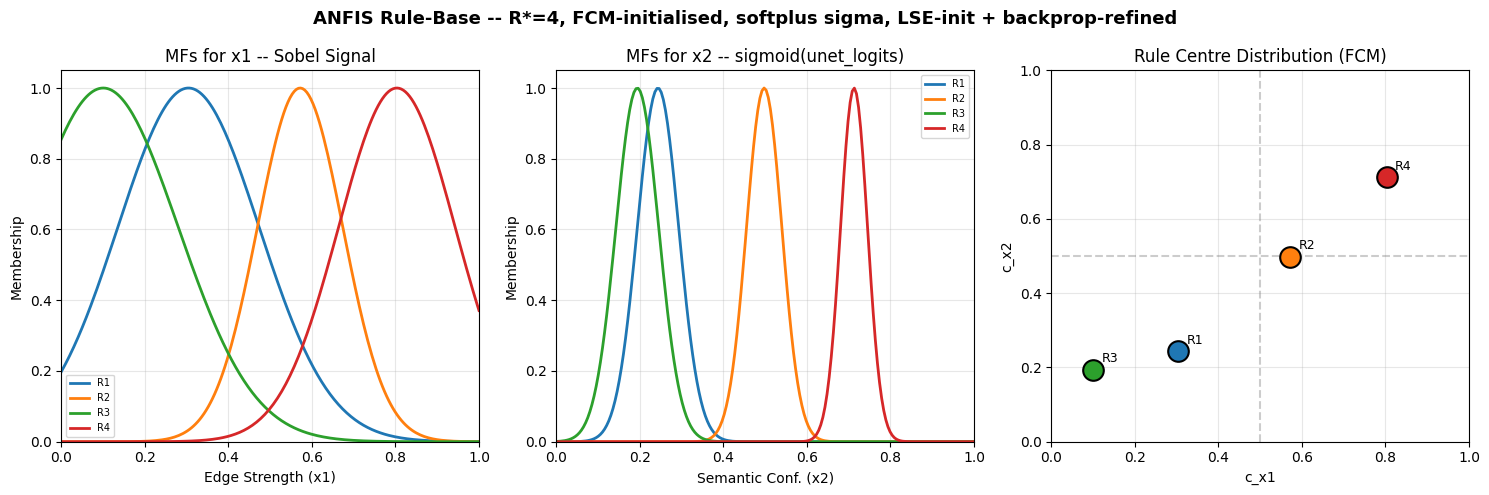

ANFIS rule-base + MF curve visualisation saved (R*=4)


In [27]:
x_range = np.linspace(0, 1, 200)
anfis_head = model.anfis_head
R = anfis_head.n_rules
theta = anfis_head.consequents.detach().cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f'ANFIS Rule-Base -- R*={R}, FCM-initialised, softplus sigma, LSE-init + backprop-refined',
             fontsize=13, fontweight='bold')
colours = plt.cm.tab10(np.linspace(0, 1, max(R, 10)))

print(f'  {"Rule":<8} {"c_x1":>8} {"sigma_x1":>10} {"c_x2":>8} {"sigma_x2":>10} {"p":>8} {"q":>8} {"r":>8}')
print('  ' + '-'*76)

for i_r, rule in enumerate(anfis_head.rules):
    cx1 = rule.mf_x1.center.item(); sx1 = rule.mf_x1.sigma.item()
    cx2 = rule.mf_x2.center.item(); sx2 = rule.mf_x2.sigma.item()
    pv, qv, rv = theta[i_r]
    m1 = np.exp(-((x_range-cx1)**2)/(2*sx1**2+1e-8))
    m2 = np.exp(-((x_range-cx2)**2)/(2*sx2**2+1e-8))
    axes[0].plot(x_range, m1, color=colours[i_r], lw=2, label=f'R{i_r+1}')
    axes[1].plot(x_range, m2, color=colours[i_r], lw=2, label=f'R{i_r+1}')
    axes[2].scatter(cx1, cx2, s=220, color=colours[i_r], edgecolors='k', lw=1.5, zorder=5)
    axes[2].annotate(f'R{i_r+1}', (cx1+0.02, cx2+0.02), fontsize=9)
    print(f'  Rule {i_r+1:<4} {cx1:>8.3f} {sx1:>10.3f} {cx2:>8.3f} {sx2:>10.3f} '
          f'{pv:>8.3f} {qv:>8.3f} {rv:>8.3f}')

for ax, xl, title in [(axes[0],'Edge Strength (x1)','MFs for x1 -- Sobel Signal'),
                       (axes[1],'Semantic Conf. (x2)','MFs for x2 -- sigmoid(unet_logits)')]:
    ax.set(xlabel=xl, ylabel='Membership', title=title, xlim=[0,1], ylim=[0,1.05])
    ax.legend(fontsize=7); ax.grid(alpha=0.3)

axes[2].axhline(0.5, color='gray', ls='--', alpha=0.4)
axes[2].axvline(0.5, color='gray', ls='--', alpha=0.4)
axes[2].set(xlabel='c_x1', ylabel='c_x2', title='Rule Centre Distribution (FCM)', xlim=[0,1], ylim=[0,1])
axes[2].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/anfis_rule_viz.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'ANFIS rule-base + MF curve visualisation saved (R*={R})')
